# Stage 2 - Exploratory Data Analysis

#### Performs Exploratory Data Analysis (EDA) on the raw Telco Customer Churn dataset by:

- Loading the `telco_churn_raw` CSV from `data\raw\telco_churn_raw.csv`,
- Conducting a brief data inspection of `telco_churn_raw.csv` to verify findings made during data profiling,
- Investigating the distribution of the target, categorical and numeric features, which answer one of the posed research questions,
- Investigating redundancy among categorical, numeric and categorical-numeric predictor pairs through various statistical measures,
- Producing nine visualisations comprising the EDA phase through the use of several helper functions, and 
- Exporting and saving all produced visuals to `reports/figures/` for subsequent stages in the project pipeline.


#### Data source: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

------------


##### $\textbf{Setup}$

##### This section covers the library imports, warning configurations, directory navigation, and plot style configurations used in the notebook.

Imports necessary libraries: `numpy` `pandas`, `itertools`, `scipy`, `math` for data cmputation and manipulation; `pyplot` `mticker`, `Patch` from `matplotlib` and `seaborn` for data visualisation; `warnings` for potential issue alerts; `os` for directory navigation:

In [1]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt                         # chart rendering
import matplotlib.ticker as mticker                     # chart axis formatting

from matplotlib.patches import Patch                    # global legend formatting
from matplotlib.colors import LinearSegmentedColormap   # chart colourmap customisation
from itertools import combinations                      # unique pair generation
from itertools import product                           # unique pair generation
from scipy.stats import chi2_contingency                # chi-squared test computation

import seaborn as sns 
import warnings
import os      

Ignores all potential warnings:

In [2]:
warnings.filterwarnings('ignore')

Navigates from notebook's location to project root, i.e. since notebooks live in `notebooks/`, goes up one level to reach project root:

In [3]:
dir_nb = os.getcwd()
project_root = os.path.dirname(dir_nb)   # retrieves project root directory     
os.chdir(project_root)                   # changes directory to project root

print(os.getcwd())                       # prints project root directory

C:\Users\Wits-User\Desktop\PROJECTS1\telco-churn-prediction


Creates `reports/figures/` directory path if it does not exist:

In [4]:
os.makedirs('reports/figures/', exist_ok = True)

Ensures generated plots are rendered and displayed directly below code:

In [5]:
%matplotlib inline

Sets a consistent visual style for all produced charts:

In [6]:
plt.rcParams.update({
    'font.family'       :  'Arial',
    'figure.dpi'        :  300,
    'axes.spines.top'   :  False,     # hides top chart border lines 
    'axes.spines.right' :  False})    # hides right chart border lines

Provides a comma sepearator option for global formatting of axis tick labels, which ensures better readability:

In [7]:
label_fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}') 

Defines a handle with labelled visual markers for global legend formatting in specified charts:

In [8]:
bar_handles = [Patch(facecolor = '#8B0000', label = 'Yes'), 
               Patch(facecolor = '#4472C4', label = 'No')] 

Defines two custom colourmaps for heatmap plotting:

In [9]:
# diverging scheme:
custom_map_1 = LinearSegmentedColormap.from_list('BlueGreyRed',
               ['#4472C4', '#EAEAF2', '#8B0000'])

# sequential single-hue scheme:
custom_map_2 = LinearSegmentedColormap.from_list('GreyRed',
               ['#EAEAF2', '#8B0000'])

##### $\textbf{Data loading and inspection}$

##### This section covers the importing of the dataset and initial data inspection prior to exploratory analysis.

Loads raw data from file:

In [10]:
churn_raw_df = pd.read_csv('data/raw/telco_churn_raw.csv')

print('Raw Telco churn prediction dataset read into dataframe!')

Raw Telco churn prediction dataset read into dataframe!


Verifies dimensions and additional structural metadata of `churn_raw_df` to programmatically confirm observations made in Stage 1 (profiling phase):

In [11]:
churn_raw_df.shape        # expected: (7043, 21)

(7043, 21)

In [12]:
churn_raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

According to the observations made during data profiling, there should be four numeric data-type columns :`SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`. However, `TotalCharges` is described as a `object` data type from the structural metadata. Additionally, $11$ empty strings (in the form of blank cells) were identified during data profiling: 

In [13]:
empty_strings = churn_raw_df['TotalCharges'].eq(" ").sum()

print(f"Number of empty strings in TotalCharges column: ", empty_strings)       # expected: 11

Number of empty strings in TotalCharges column:  11


Samples $10$ random row entries from `churn_raw_df` for an initial observation:

In [14]:
churn_raw_df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2914,0484-FFVBJ,Male,0,No,No,32,Yes,No,DSL,No,...,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),64.85,2010.95,No
5524,1716-LSAMB,Male,0,Yes,Yes,45,Yes,No,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),54.65,2553.7,No
6996,4174-LPGTI,Female,0,Yes,Yes,41,Yes,No,DSL,No,...,No,Yes,No,Yes,One year,Yes,Bank transfer (automatic),66.50,2728.6,Yes
1662,2058-DCJBE,Male,0,No,No,5,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.75,324.6,Yes
782,0285-INHLN,Male,0,Yes,Yes,27,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),54.75,1510.3,No
4700,5365-LLFYV,Female,0,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,45.85,105.6,No
3869,1357-BIJKI,Male,0,Yes,No,50,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,One year,Yes,Electronic check,98.25,4858.7,No
1460,2952-QAYZF,Male,0,No,No,5,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,85.30,424.15,Yes
6703,2737-WFVYW,Female,0,No,No,2,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,45.25,85.5,Yes
2538,7758-UJWYS,Male,0,Yes,Yes,34,No,No phone service,DSL,No,...,No,Yes,Yes,No,Two year,Yes,Electronic check,40.55,1325.85,No


##### $\textbf{Target Class Distribution}$

##### This section explores the distribution of the target classes based on whether a customer was retained (`Yes`) or churned (`No`).

Determines the total number of entries each target class has in `churn_raw_df` by determining value counts and proportions of the `Churn` column, in turn confirming the class distribution determined during data profiling: 

In [15]:
counts = churn_raw_df['Churn'].value_counts()

# computes churn class proportion as percentages:
percentages = (churn_raw_df['Churn'].value_counts(normalize = True) * 100).round(2)

# prints target class value counts and corresponding proportions:
print(f"Total proportions of non-churning and churning customers:"
      f"\nRetained (No)  = {counts.values[0]} ({percentages.values[0]}%)"        # expected: 5174 (73.46%)
      f"\nChurned  (Yes) = {counts.values[1]} ({percentages.values[1]}%)")       # expected: 1869 (26.54%)

Total proportions of non-churning and churning customers:
Retained (No)  = 5174 (73.46%)
Churned  (Yes) = 1869 (26.54%)


Produces a visual of the target class distribution in the form of a horizontal bar graph:

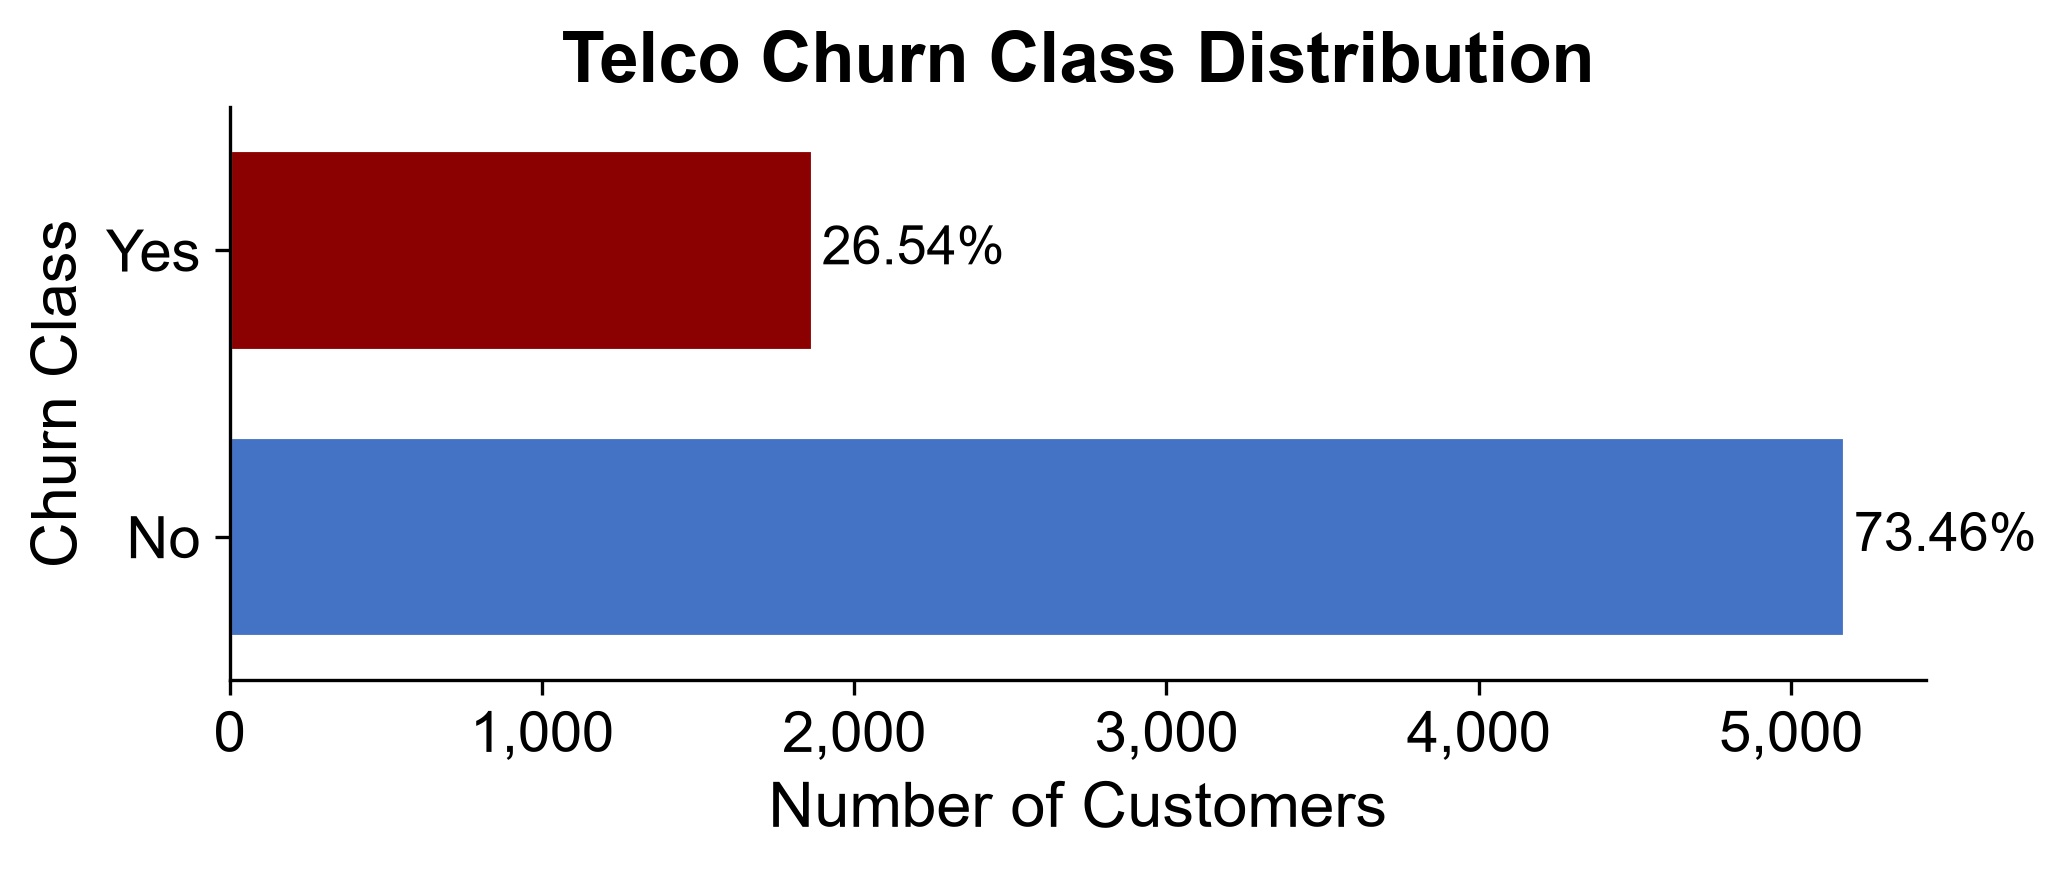

In [16]:
fig1, ax1 = plt.subplots(figsize = (7,3))

class_bars = ax1.barh(counts.index,
                      counts.values,
                      color = ['#4472C4', '#8B0000'],
                      edgecolor = 'white',
                      height = 0.7)

# adds percentage symbol to percentage values:
percentage_labels = [f"{pcnt}%" for pcnt in percentages.values]

ax1.bar_label(class_bars, labels = percentage_labels, padding = 2, fontsize = 13)

# chart formatting:
ax1.xaxis.set_major_formatter(label_fmt)              # calls global axis tick formatting              
ax1.set_ylim(-0.5, 1.5)
ax1.tick_params(axis = 'both', labelsize = 14)
ax1.set_xlabel('Number of Customers', fontsize = 15)
ax1.set_ylabel('Churn Class', fontsize = 15)
ax1.set_title('Telco Churn Class Distribution', fontsize = 17, fontweight = 'bold')

plt.tight_layout()                                    # ensures smooth readability
plt.savefig('reports/figures/target_class_bar_chart.png', dpi = 300, bbox_inches = 'tight')
plt.show()

##### $\textbf{Interpretation (Target Class Distribution)}$

Evidently, the class distribution of the Telco churn dataset is heavily imbalanced, with total retained customers being almost $3$ times larger ($73.46\%$) than total customers that churned ($26.54\%$). As such, the $\sim26/74$ class split influences every downstream modelling decision, including the approach to dealing with the class imbalance (class weighting), and
the prioritisation of classification evaluation metrics (AUC-ROC, recall, precision and F1 score over accuracy). This is addressed further in subsequent stages of the project pipeline.

##### $\textbf{Categorical feature distributions}$

##### This section explores the structure and distribution of the categorical features in relation to customer churn and retention. Each feature is investigated according to the number of category labels it has: $2$ categories (`gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`), or $3$ categories (`MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). Furthermore, the rate of churning customers is explored through specific categorical features `Contract` and `PaymentMethod`. 

Defines a function `confirm_categories` that extracts specified features (and corresponding target class) into a dataframe, and verifies the number of categories for each feature:

In [17]:
def confirm_categories(original_df, features, new_df_name):
    """
    Extracts specified features from a dataframe into a separate named dataframe, and verifies the 
    number of categories for each feature.

    Arguments:
               original_df (pandas.Dataframe) : Original dataframe from which features are extracted.
               features         (list object) : Feature names, passed as a list of strings. 
               new_df_name       (str object) : Name of newly created dataframe, passed as a string.
    Output:
               cat_df      (pandas.Dataframe) : New dataframe with extracted features.            
    """
    # makes a copy of features list to avoid global modification:
    feature_names = features.copy()
    
    churn = 'Churn'
    feature_names.append(churn)
    
    cat_df = original_df[feature_names]

    # confirms the number of categories for each feature in the created dataframes:
    cat_unique = cat_df.drop(columns = ['Churn']).nunique()

    print(f'Number of categories for each feature in {new_df_name}:\n', cat_unique, sep = '')

    return cat_df

Extracts and categorical features into three seperate dataframes and verifies number of categories per feature via `confirm_categories`:

In [18]:
two_cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
three_cat_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
rate_cat_features = ['Contract', 'PaymentMethod']

two_cat_df = confirm_categories(original_df = churn_raw_df, 
                                features = two_cat_features, 
                                new_df_name = 'two_cat_df')         # expected: 2 for each feature

three_cat_df = confirm_categories(original_df = churn_raw_df, 
                                  features = three_cat_features, 
                                  new_df_name = 'three_cat_df')     # expected: 3 for each feature

rate_cat_df = confirm_categories(original_df = churn_raw_df, 
                                 features = rate_cat_features, 
                                 new_df_name = 'rate_cat_df')     # expected: 3 for 'Contract', and 4 for 'PaymentMethod'

Number of categories for each feature in two_cat_df:
gender              2
SeniorCitizen       2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
dtype: int64
Number of categories for each feature in three_cat_df:
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
dtype: int64
Number of categories for each feature in rate_cat_df:
Contract         3
PaymentMethod    4
dtype: int64


Defines a function `compute_count_percentages` that determines the total number of entries each categorical feature label has by computing value counts and percentage proportions of the labels:

In [19]:
def compute_count_percentages(feature_df):
    """
    Determines total value counts and corresponding percentage proportions for each label in all categorical features of a specified
    dataframe.

    Arguments: 
              feature_df (pandas.DataFrame) : DataFrame containing the categorical features, their label entries and the corresponding 
                                              target class.

    Output: 
              counts          (dict object) : Dictionary with value counts for every category-class pair of each feature, stored in 
                                              a dataframe. 
              percentages     (dict object) : Dictionary with percentage proportions for every churning category-class pair of each 
                                              feature, stored in a dataframe.       
    """
    columns = feature_df.columns.tolist()   # extracts feature names
    
    del columns[-1]                         # removes target column name 'Churn'             

    # computes label counts for every category-class pair per feature, with unstack() for pivoting class index from row to column:
    counts = {feature: feature_df.groupby([feature, 'Churn'])['Churn'].count().unstack() for feature in columns}

    # computes label proportions of every category-class pair for churners only:
    props = {feature: (feature_df.groupby(feature)['Churn'].apply(lambda churn: (churn == 'Yes').mean()) * 100).round(2) for feature in columns}

    # appends '%' symbol to proportions in two_cat_pcnt_prop:
    percentages = {feature: props[feature].map(lambda pcnt: f"{pcnt}%") for feature, series in props.items()}

    return counts, percentages

Determines value counts and proportions of each categorical feature in `two_cat_df`, `three_cat_df` and `rate_cat_df` via `compute_count_percentages`:

In [20]:
two_cat_counts, two_cat_percentages = compute_count_percentages(two_cat_df)
three_cat_counts, three_cat_percentages = compute_count_percentages(three_cat_df)
rate_cat_counts, rate_cat_percentages = compute_count_percentages(rate_cat_df)

Defines a function `plot_cat_bars` for plotting the categorical distribution of each feature:

In [21]:
def plot_cat_bars(counts, percentages, feature, axes, y_label):
    """
    Produces formatted horizontal bar chart displaying the distribution of category labels for a singular 
    feature with a specified axes object and y-axis label.

    Arguments:
              counts      (dict object) : Dictionary with value counts for every category-class pair of
                                          each feature, stored in a dataframe. 
              percentages (dict object) : Dictionary with percentage proportions for every churning
                                          category-class pair of each feature, stored in a dataframe. 
              feature      (str object) : Feature name, passed as a string. 
              axes          (ax object) : Axes object for bar plot. 
              y_label      (str object) : Label of y-axis, passed as a string.
    """
    counts[feature].plot(kind = 'barh',
                         stacked = True,
                         ax = axes,
                         color = {'Yes': '#8B0000', 'No': '#4472C4'},
                         width = 0.4,
                         legend = False)

    # annotates each category bar with percentage proportion of churners: 
    axes.bar_label(axes.containers[1], labels = percentages[feature].values, padding = 4, fontsize = 10)

    axes.xaxis.set_major_formatter(label_fmt)             
    axes.tick_params(axis = 'both', labelsize = 10)
    axes.set_xlabel('Number of Customers', fontsize = 11)
    axes.set_ylabel(y_label, fontsize = 11)
    axes.set_title(feature, fontsize = 13)

Defines a function `plot_features_grid` that produces a visual comprising horizontal bar charts per feature and saves it to file with a specified file name:

In [22]:
def plot_features_grid(counts, percentages, nrows, ncols, fig_size, y_label, global_title, filename):
    """
    Produces and saves (to file) a formatted visual comprising horizontal bar charts that display the 
    distribution of labels for several features with specified axes objects and y-axis labels.

    Arguments:
              counts         (dict object) : Dictionary with value counts for every category-class pair
                                             of each feature, stored in a dataframe. 
              percentages    (dict object) : Dictionary with percentage proportions for every churning
                                             category-class pair of each feature, stored in a dataframe. 
              nrows           (int object) : Number of rows in subplot grid, passed as an integer.
              ncols           (int object) : Number of columns in subplot grid, passed as an integer.
              fig_size      (tuple object) : Dimensions of plot, passed as a tuple. 
              y_label    (str/list object) : Label of y-axis, passed as a string or list.
              global_title    (str object) : Global title of figure, passed as a string.
              filename        (str object) : Name of visual saved to file, passed as a string.
    """
    figure, axes = plt.subplots(nrows, ncols, figsize = fig_size, layout = 'constrained', sharex = True)

    # specifies that if 'y_label' is a singular string, each subplot shares the same y-axis label.
    # Otherwise, each subplot y-axis label is assigned a string from a list of strings:
    
    if isinstance(y_label, str):
       # iteratively produces bars and formatting for each feature via plot_cat_bars, with
       # flatten() for transforming rows of axes into individual axes objects: 
       for feature, ax in zip(list(counts.keys()), axes.flatten()):
           plot_cat_bars(counts, percentages, feature, ax, y_label)
    else:
        for feature, ax, label in zip(list(counts.keys()), axes.flatten(), y_label):
            plot_cat_bars(counts, percentages, feature, ax, label) 
            
    # places global legend below subplots at a fixed distance of 0.5 inches below bottom 
    # axes:

    figure.legend(handles = bar_handles, loc = 'outside lower center', 
                  bbox_to_anchor = (0.5, -0.5 / fig_size[1]), 
                  ncols = 2, title = 'Churn', title_fontsize = 12)

    # adds global figure title:
    plt.suptitle(global_title, fontsize = 18, fontweight = 'bold')
    plt.tight_layout()
    plt.savefig(f'reports/figures/{filename}.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

Produces a visual of the two-label categorical features via `plot_features_grid`:

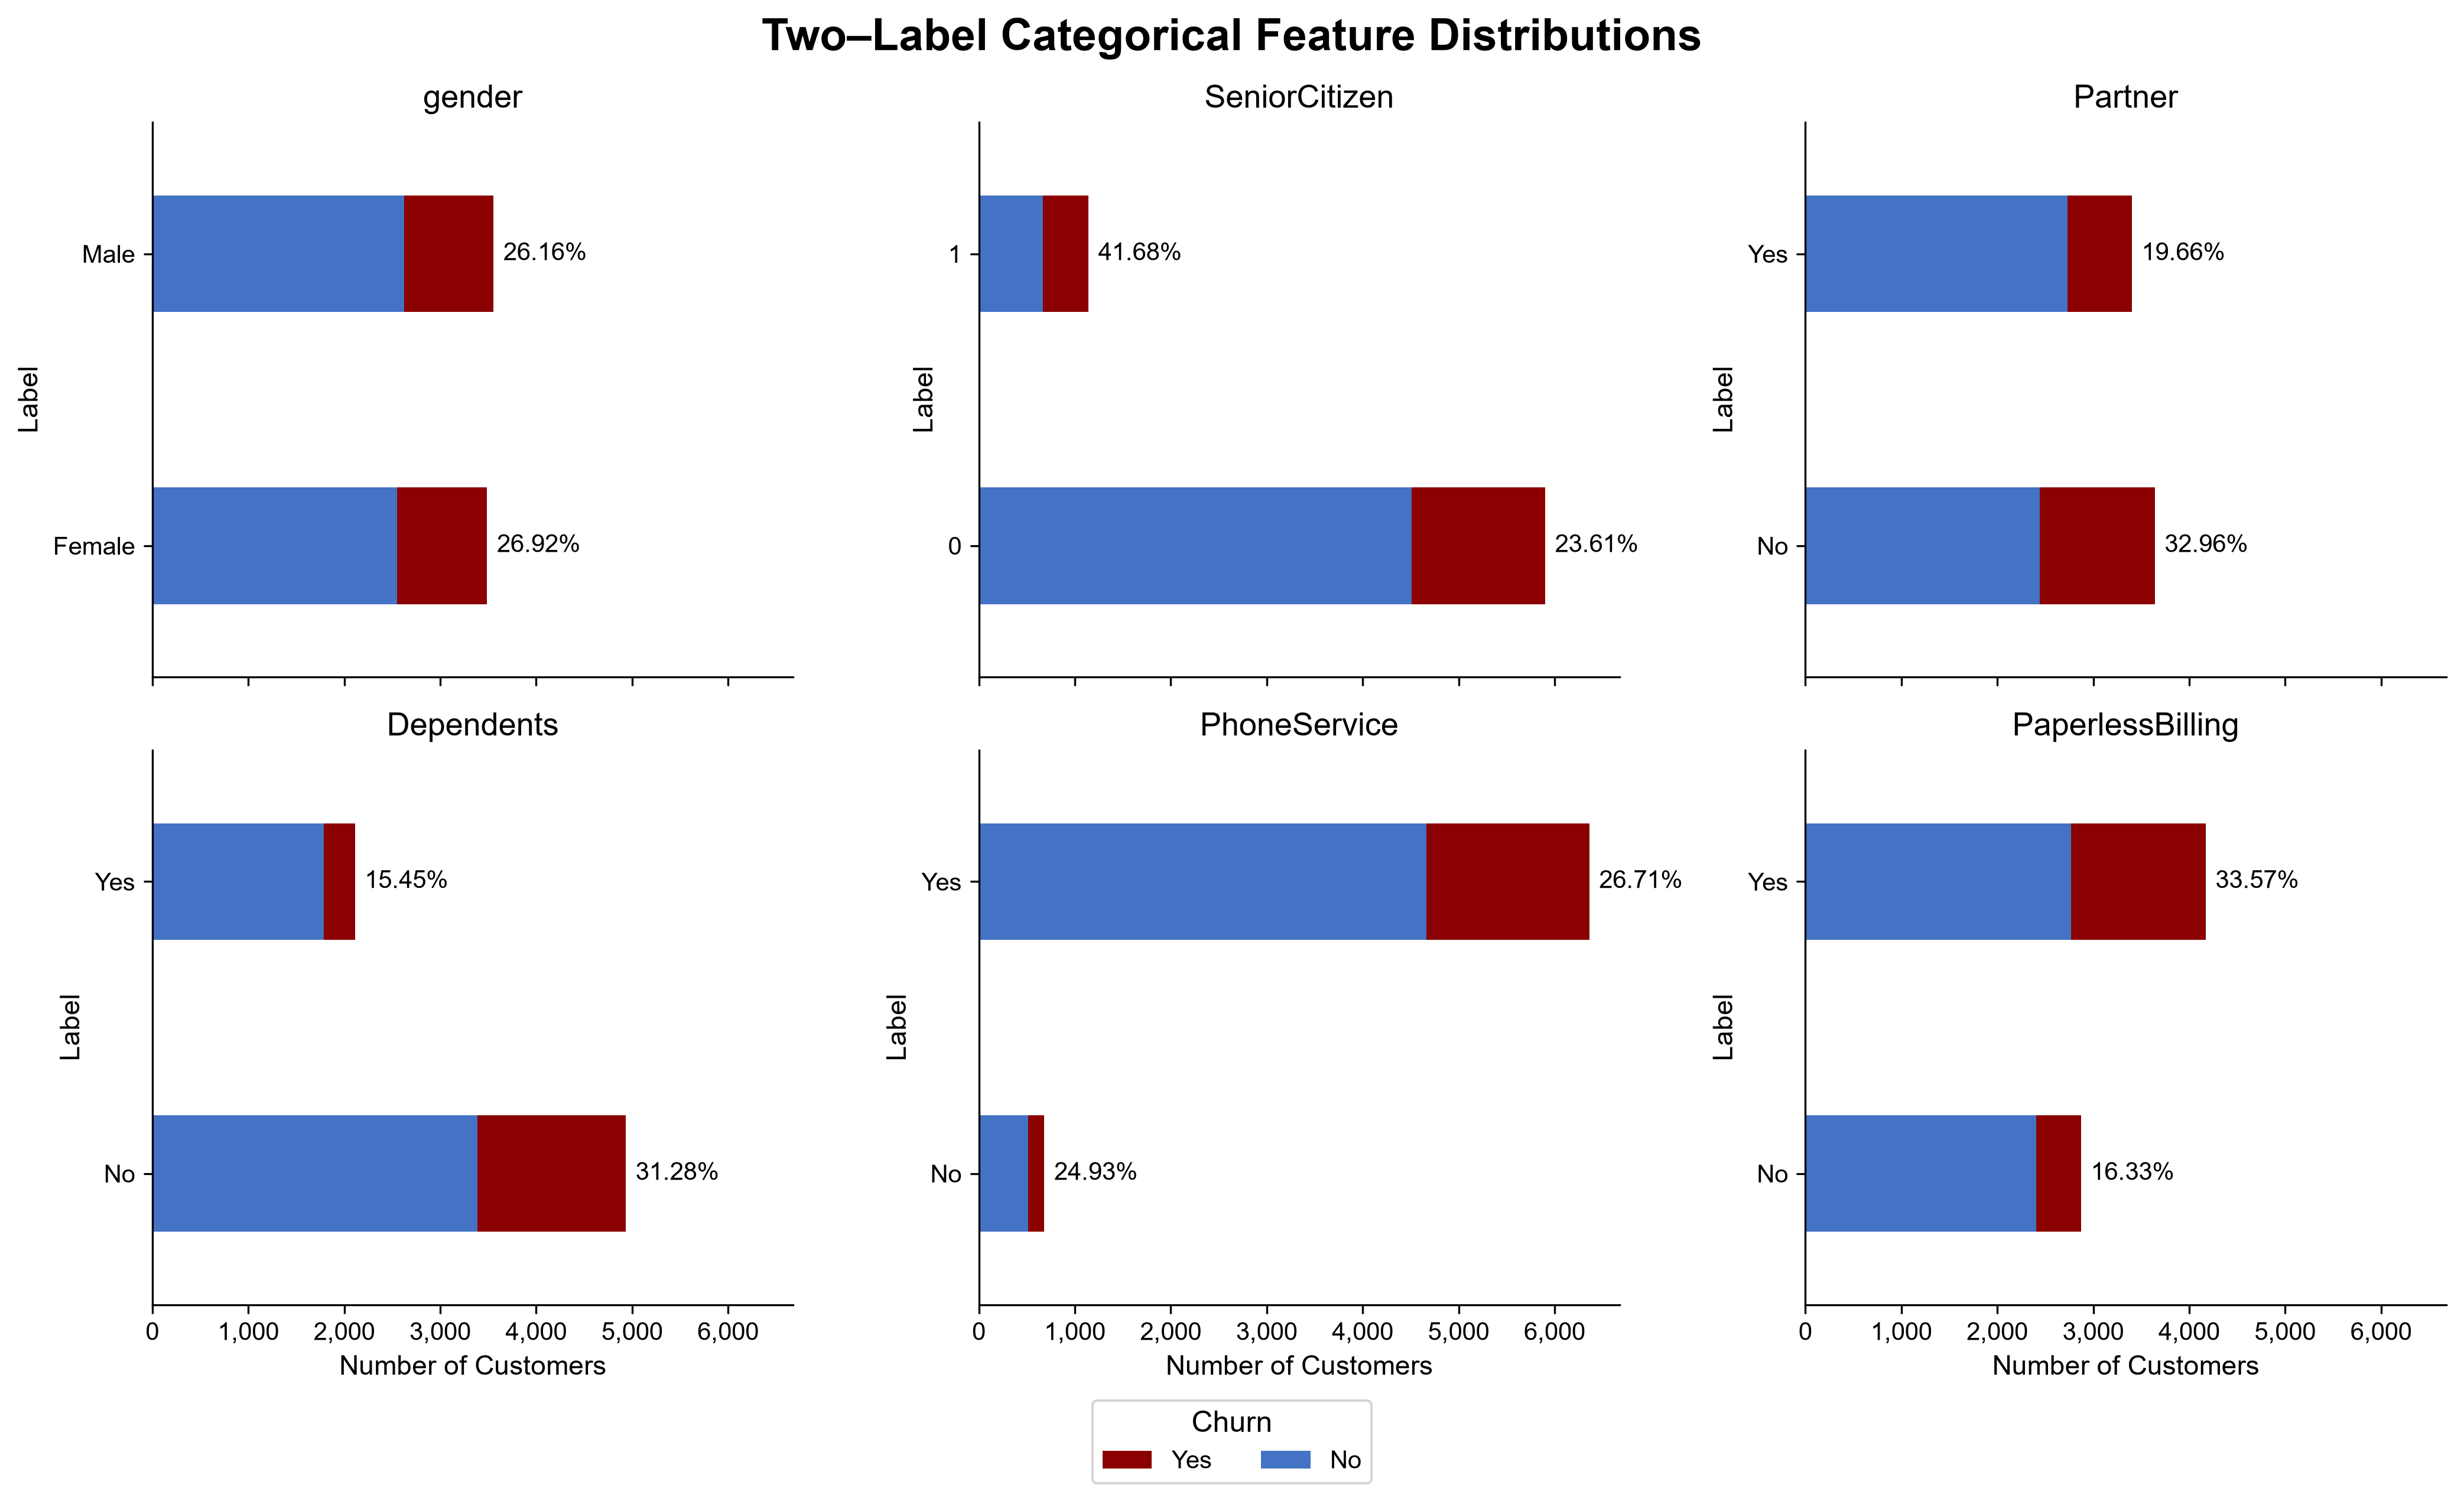

In [23]:
plot_features_grid(counts = two_cat_counts, 
                   percentages = two_cat_percentages, 
                   nrows = 2, ncols = 3, 
                   fig_size = (14,8),
                   y_label = 'Label' , 
                   global_title = 'Two\u2013Label Categorical Feature Distributions',
                   filename = 'two_cat_feature_distributions')

Produces a visual of the three-label categorical features via `plot_features_grid`:

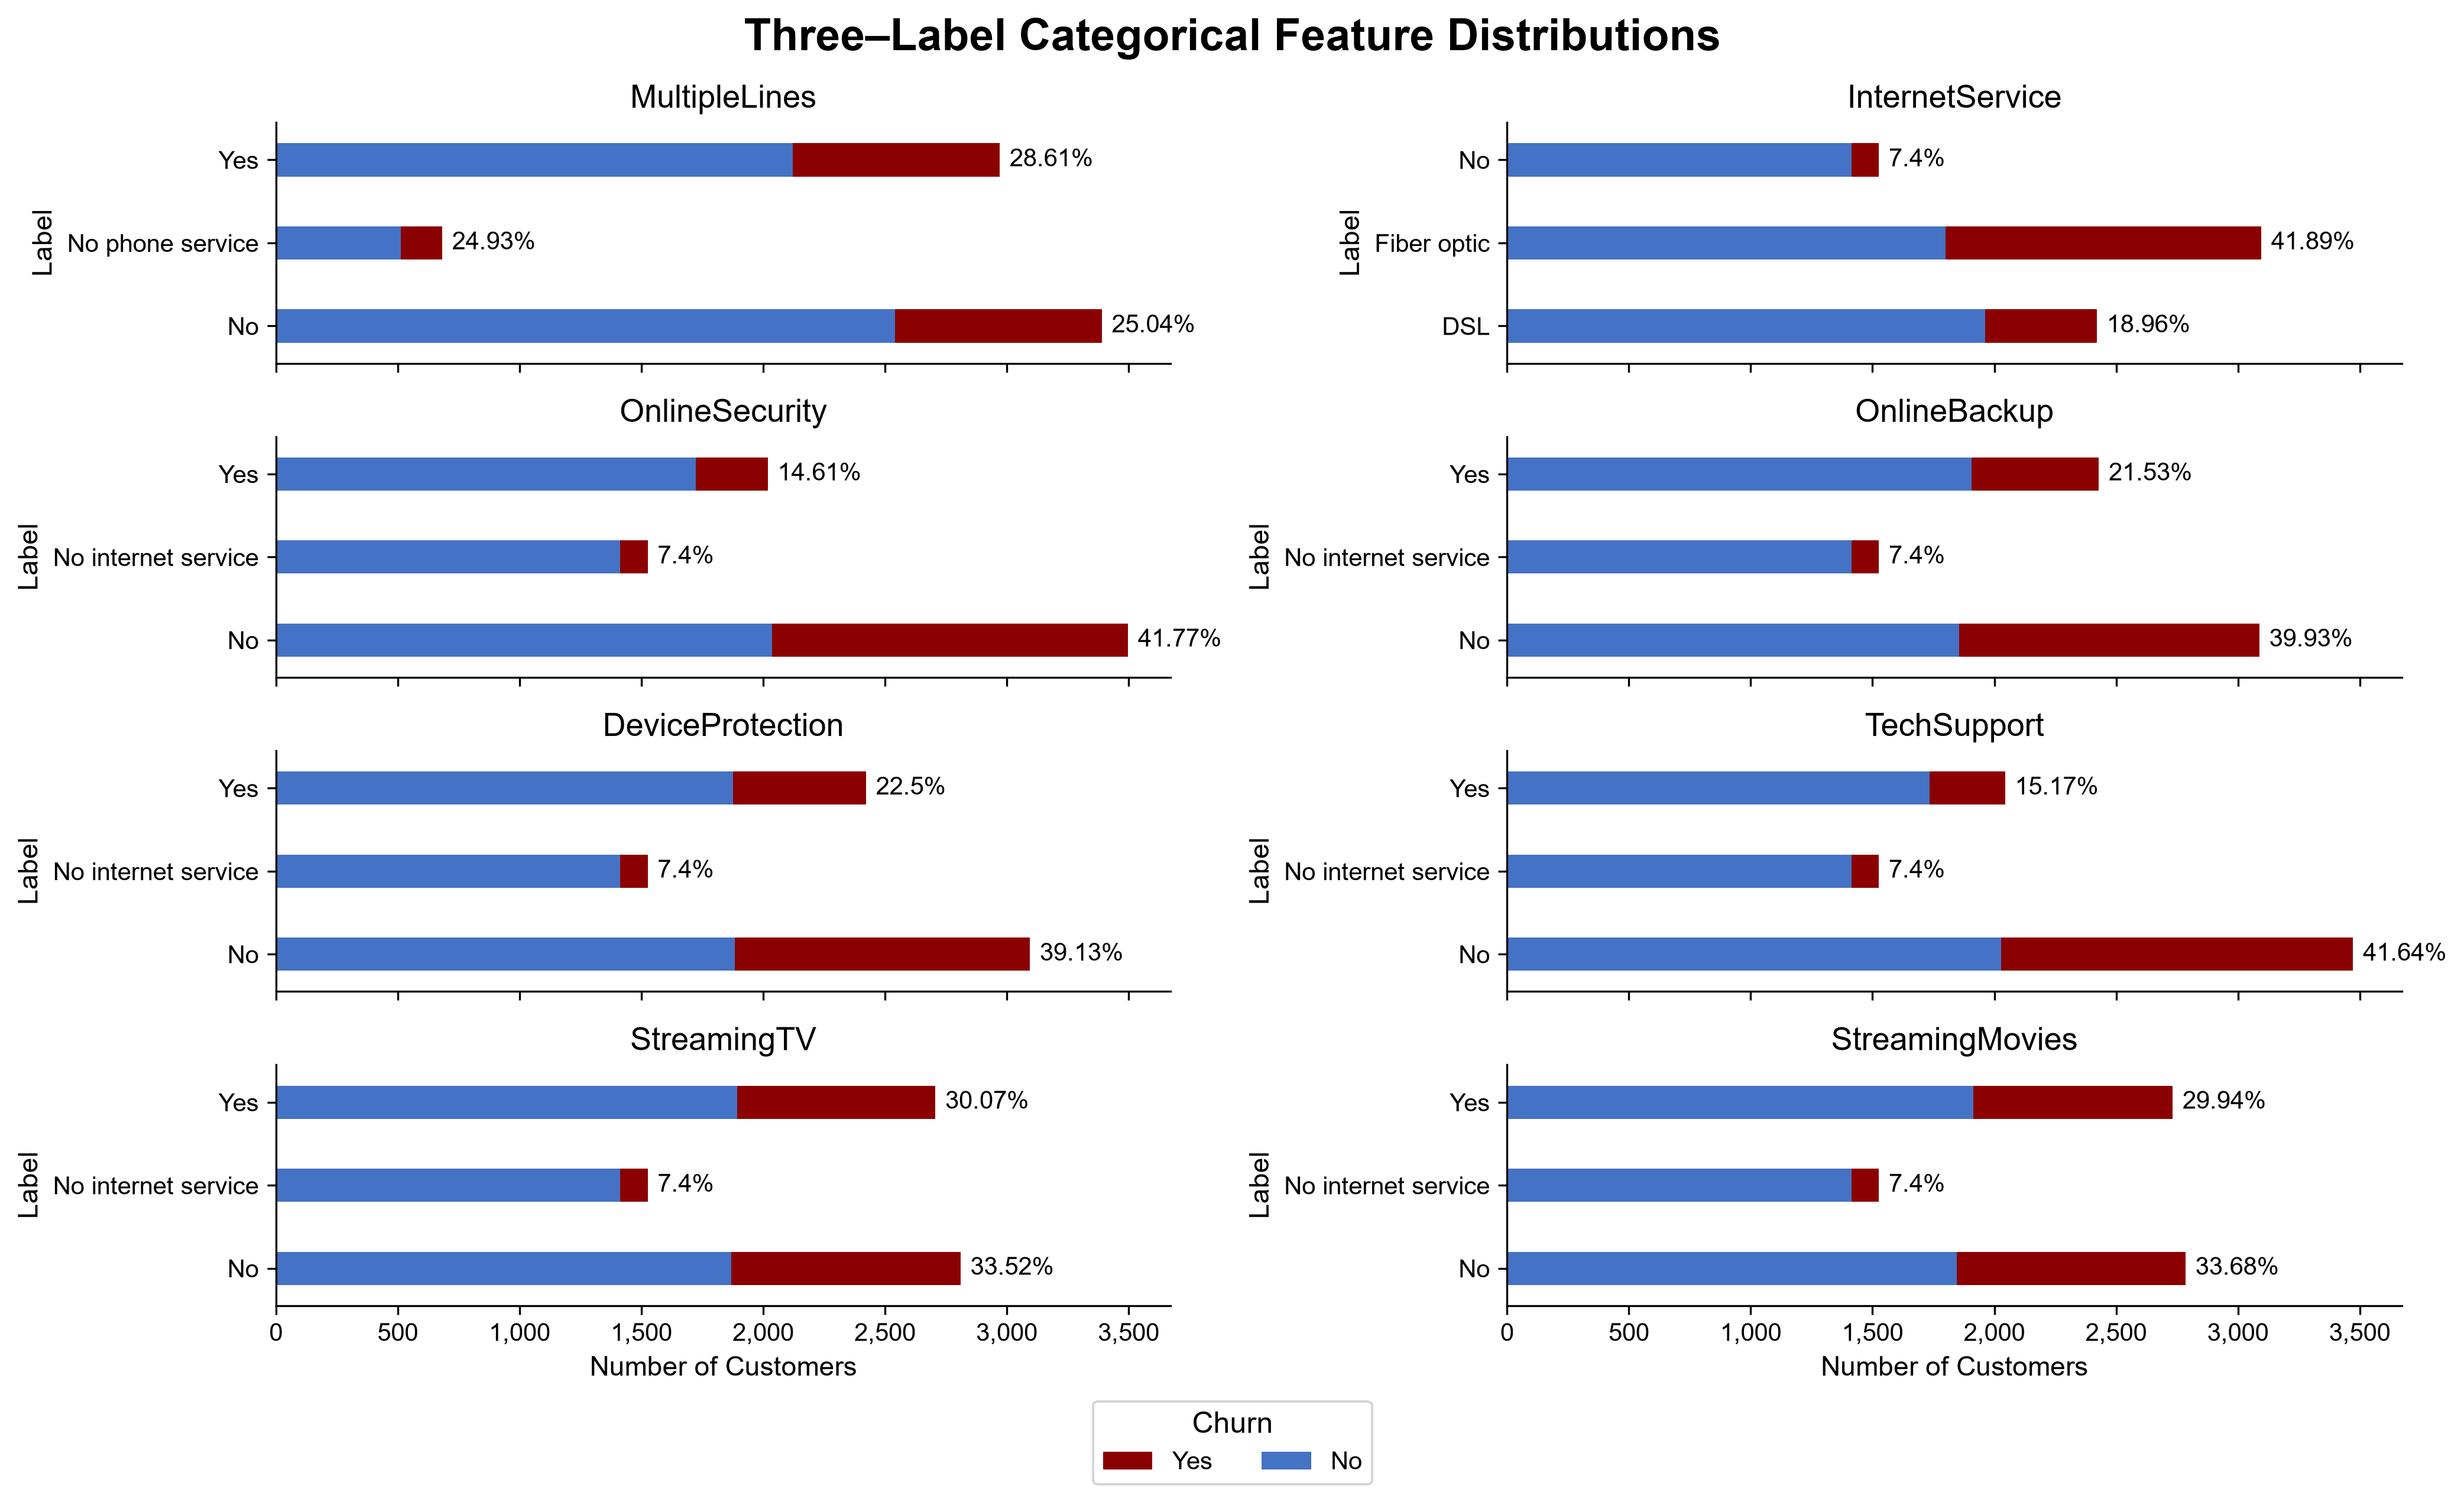

In [24]:
plot_features_grid(counts = three_cat_counts, 
                   percentages = three_cat_percentages, 
                   nrows = 4, ncols = 2, 
                   fig_size = (14,8),
                   y_label = 'Label' , 
                   global_title = 'Three\u2013Label Categorical Feature Distributions',
                   filename = 'three_cat_feature_distributions')

Produces a visual of categorical features `Contract` and `PaymentMethod` via `plot_features_grid` for a churn rate breakdown by categorical features:

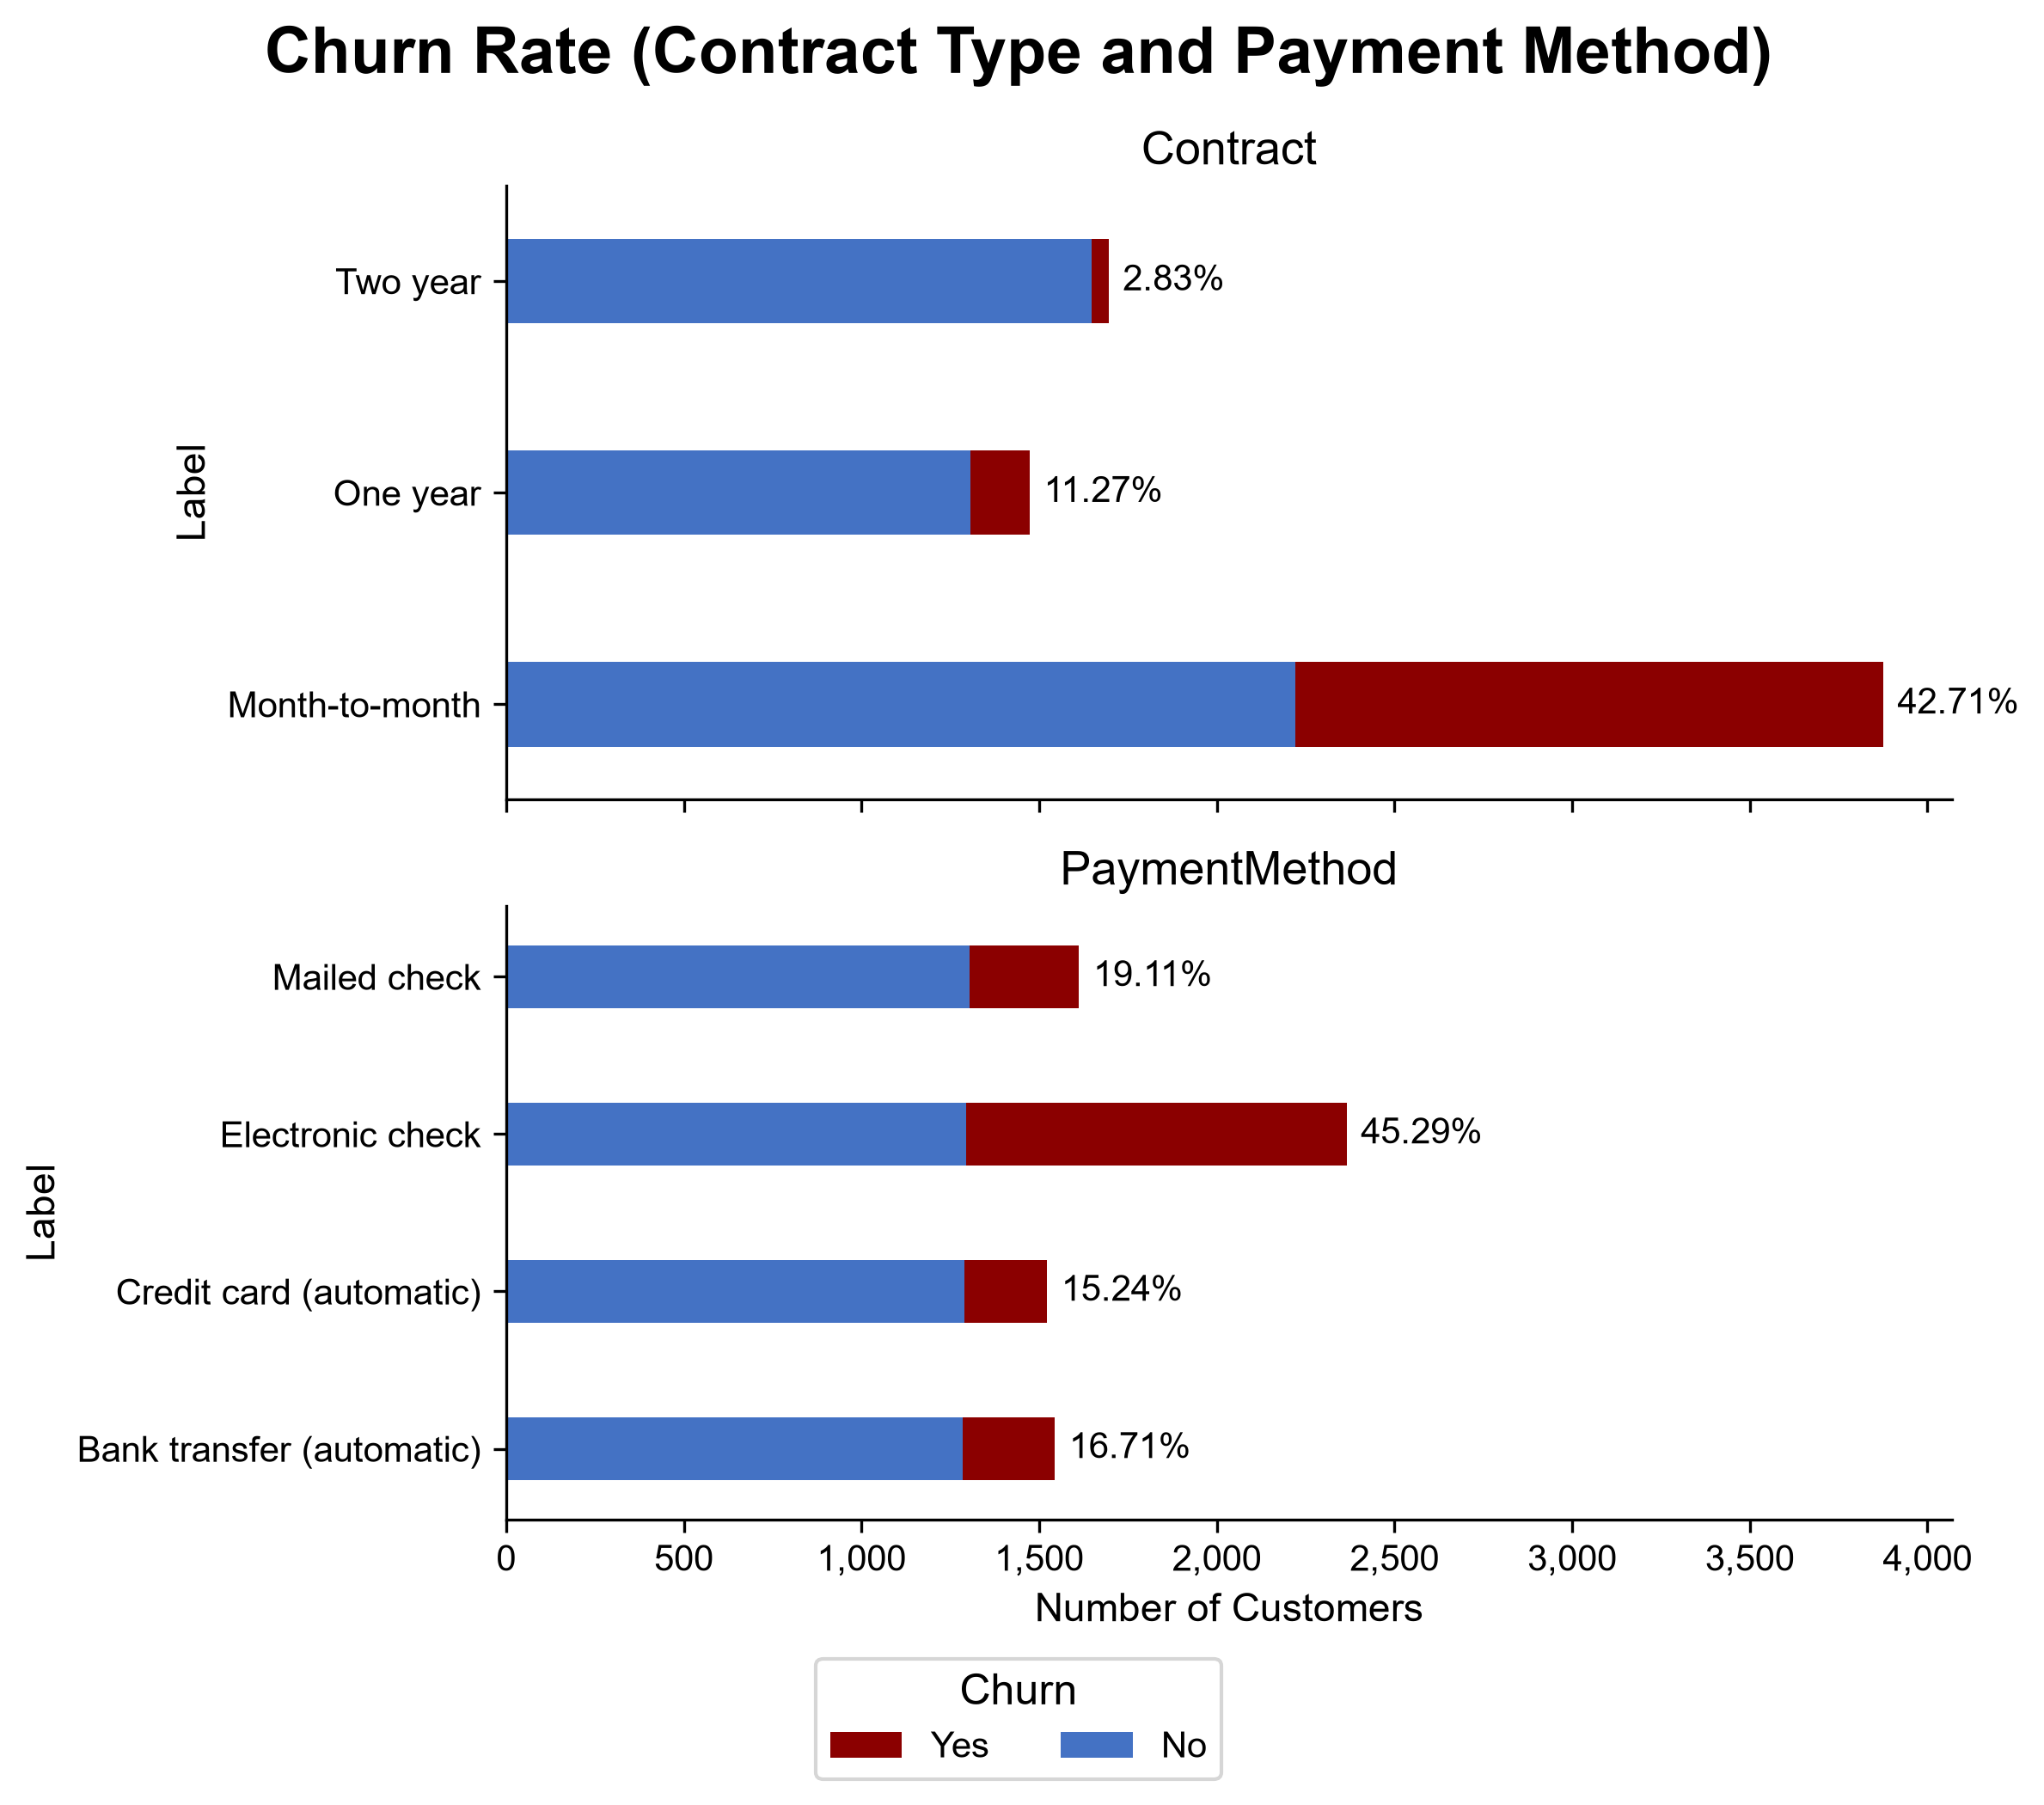

In [25]:
plot_features_grid(counts = rate_cat_counts, 
                   percentages = rate_cat_percentages, 
                   nrows = 2, ncols = 1, 
                   fig_size = (8,6.5),
                   y_label = 'Label' , 
                   global_title = 'Churn Rate (Contract Type and Payment Method)',
                   filename = 'cat_churn_rate_breakdown')

##### $\textbf{Interpretation (Categorical feature distributions)}$

Two-category features:

- `gender`:

- `SeniorCitizen`:

- `Partner`:

- `Dependents`:

- `PhoneService`:

- `PaperlessBilling`:

Three-category features:

- `MultipleLines`:

- `InternetService`:

- `OnlineSecurity`:

- `OnlineBackup`:

- `DeviceProtection`:

- `TechSupport`:

- `StreamingTV`:

- `StreamingMovies`:

Churn Rate by contract type and payment method:

- `Contract`:

- `PaymentMethod`:

##### $\textbf{Numeric feature distributions}$

##### This section explores the structure and distribution of numeric features `tenure`, `MonthlyCharges`, and `TotalCharges` in relation to customer churn and retention. Furthermore, the rate of churning customers is explored through specific numeric features `tenure` and `MonthlyCharges`. 

Extracts specified numeric features (and their corresponding target class) into dataframe `numeric_df` and converts `TotalCharges` feature entries to numeric:

In [26]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
num_features.append('Churn')
numeric_df = churn_raw_df[num_features]

# converts valid 'TotalCharges' feature entries to numeric, with invalid strings transformed into NaN:
numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'], errors = 'coerce')

numeric_df.describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


Evidently, there are $7032$ valid numeric entries in `TotalCharges` in comparison to the total $7043$ entries for `tenure` and `MonthlyCharges`, confirming the $11$ empty strings and their transformation to $NaN$. The ranges of the numeric features are as follows: $0 - 72$ months for `tenure`, $\$18.25 - \$118.75$ for `MonthlyCharges`, and $\$18.80 - \$8684.80$ for `TotalCharges`.

Incidently, when investigating the row entries of `numeric_df` containing the $11$ blank `TotalCharges` (`NaN`) entries, it is observed that all the entries have a `tenure` value of $0$:

In [27]:
TotalCharges_empty_df = numeric_df[numeric_df['TotalCharges'].isnull()]
TotalCharges_empty_df

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In context, the blank `TotalCharges` values make coherent sense, as customers with no tenure are new sign ups with their first billing cycle being incomplete, thus accruing no total charge as yet. Furthermore, all $11$ customers with no total charges (and no tenure) are observed to be non-churners, which has already been determined as the majority target class ($\sim26/74$ split). This observation influences the manner in which the rows containing the blank entries are handled in the data preparation stage of the project pipeline. 

Defines a function `plot_hist` that produces a histogram for each numeric feature:  

In [28]:
def plot_hist(feature_df, feature, bin_edges, x_label, axes, rotation, xlabel_bins = None):
    """
    Produces a formatted histogram for a binned numeric feature with specified bin edges
    and axes.

    Arguments:
               feature_df (pandas.DataFrame) : DataFrame containing the numeric features, their 
                                               label entries and the corresponding target class.
               feature          (str object) : Feature name, passed as a string.
               bin_edges      (array object) : Numeric bin edges, passed as an array.
               x_label          (str object) : Label of x-axis, passed as a string.
               axes              (ax object) : Axes object for histogram plot. 
               rotation         (int object) : Rotation angle of x-ticks, passed as an integer. 
               xlabel_bins    (array object) : Numeric labels for x-ticks, passed as an array.
    """
    sns.histplot(data = feature_df,
                 x = feature,
                 hue = 'Churn',
                 ax = axes, 
                 multiple = 'stack',
                 palette = {'Yes': '#8B0000', 'No': '#4472C4'},
                 bins = bin_edges,
                 alpha = 1,
                 legend = False)

    # specifies that if xlabel_bins = None, then the labels for x-ticks are equivalent
    # to the bin edges:
    if xlabel_bins is None:
       xlabel_bins = bin_edges
    
    # plot formatting:
    axes.tick_params(axis = 'both', labelsize = 11)
    axes.set_xticks(xlabel_bins)
    axes.tick_params(axis = 'x', rotation = rotation)
    axes.set_xlabel(x_label, fontsize = 12)
    axes.set_ylabel('Number of Customers', fontsize = 12)
    axes.set_title(feature, fontsize = 13)

Defines parameters to pass to `plot_hist` for histogram plotting of numeric features:

In [29]:
# defines equidistant bins for each histogram plot:
tenure_bins = np.arange(0, 76, 5)                  # 15 bins for 'tenure'
MonthlyCharges_bins = np.arange(0, 121, 10)        # 12 bins for 'MonthlyCharges'
TotalCharges_bins = np.arange(0, 8701, 435)        # 20 bins for 'TotalCharges'

# defines x-tick labels for each histogram plot:
tenure_labels = np.arange(0,76,15)
MonthlyCharges_labels = None
TotalCharges_labels = np.arange(0, 8701, 1740)

# Defines feature dictionaries containing each parameter: 
tenure_dict = {'feature': 'tenure', 
               'bins': tenure_bins, 
               'xlabel_bins': 'Tenure Months',
               'rotation': 0, 
               'tick_labels': tenure_labels}

MonthlyCharges_dict = {'feature': 'MonthlyCharges',
                       'bins': MonthlyCharges_bins, 
                       'xlabel_bins': 'Amount (USD)',
                       'rotation': 0,
                       'tick_labels': MonthlyCharges_labels}

TotalCharges_dict = {'feature': 'TotalCharges',
                     'bins': TotalCharges_bins,
                     'xlabel_bins': 'Amount (USD)',
                     'rotation': 45,
                     'tick_labels': TotalCharges_labels}

# Defines list of feature dictionaries:
dicts_list = [tenure_dict, MonthlyCharges_dict, TotalCharges_dict]

Produces a visual of the numeric feature distributions in the form of histograms via `plot_hist`:

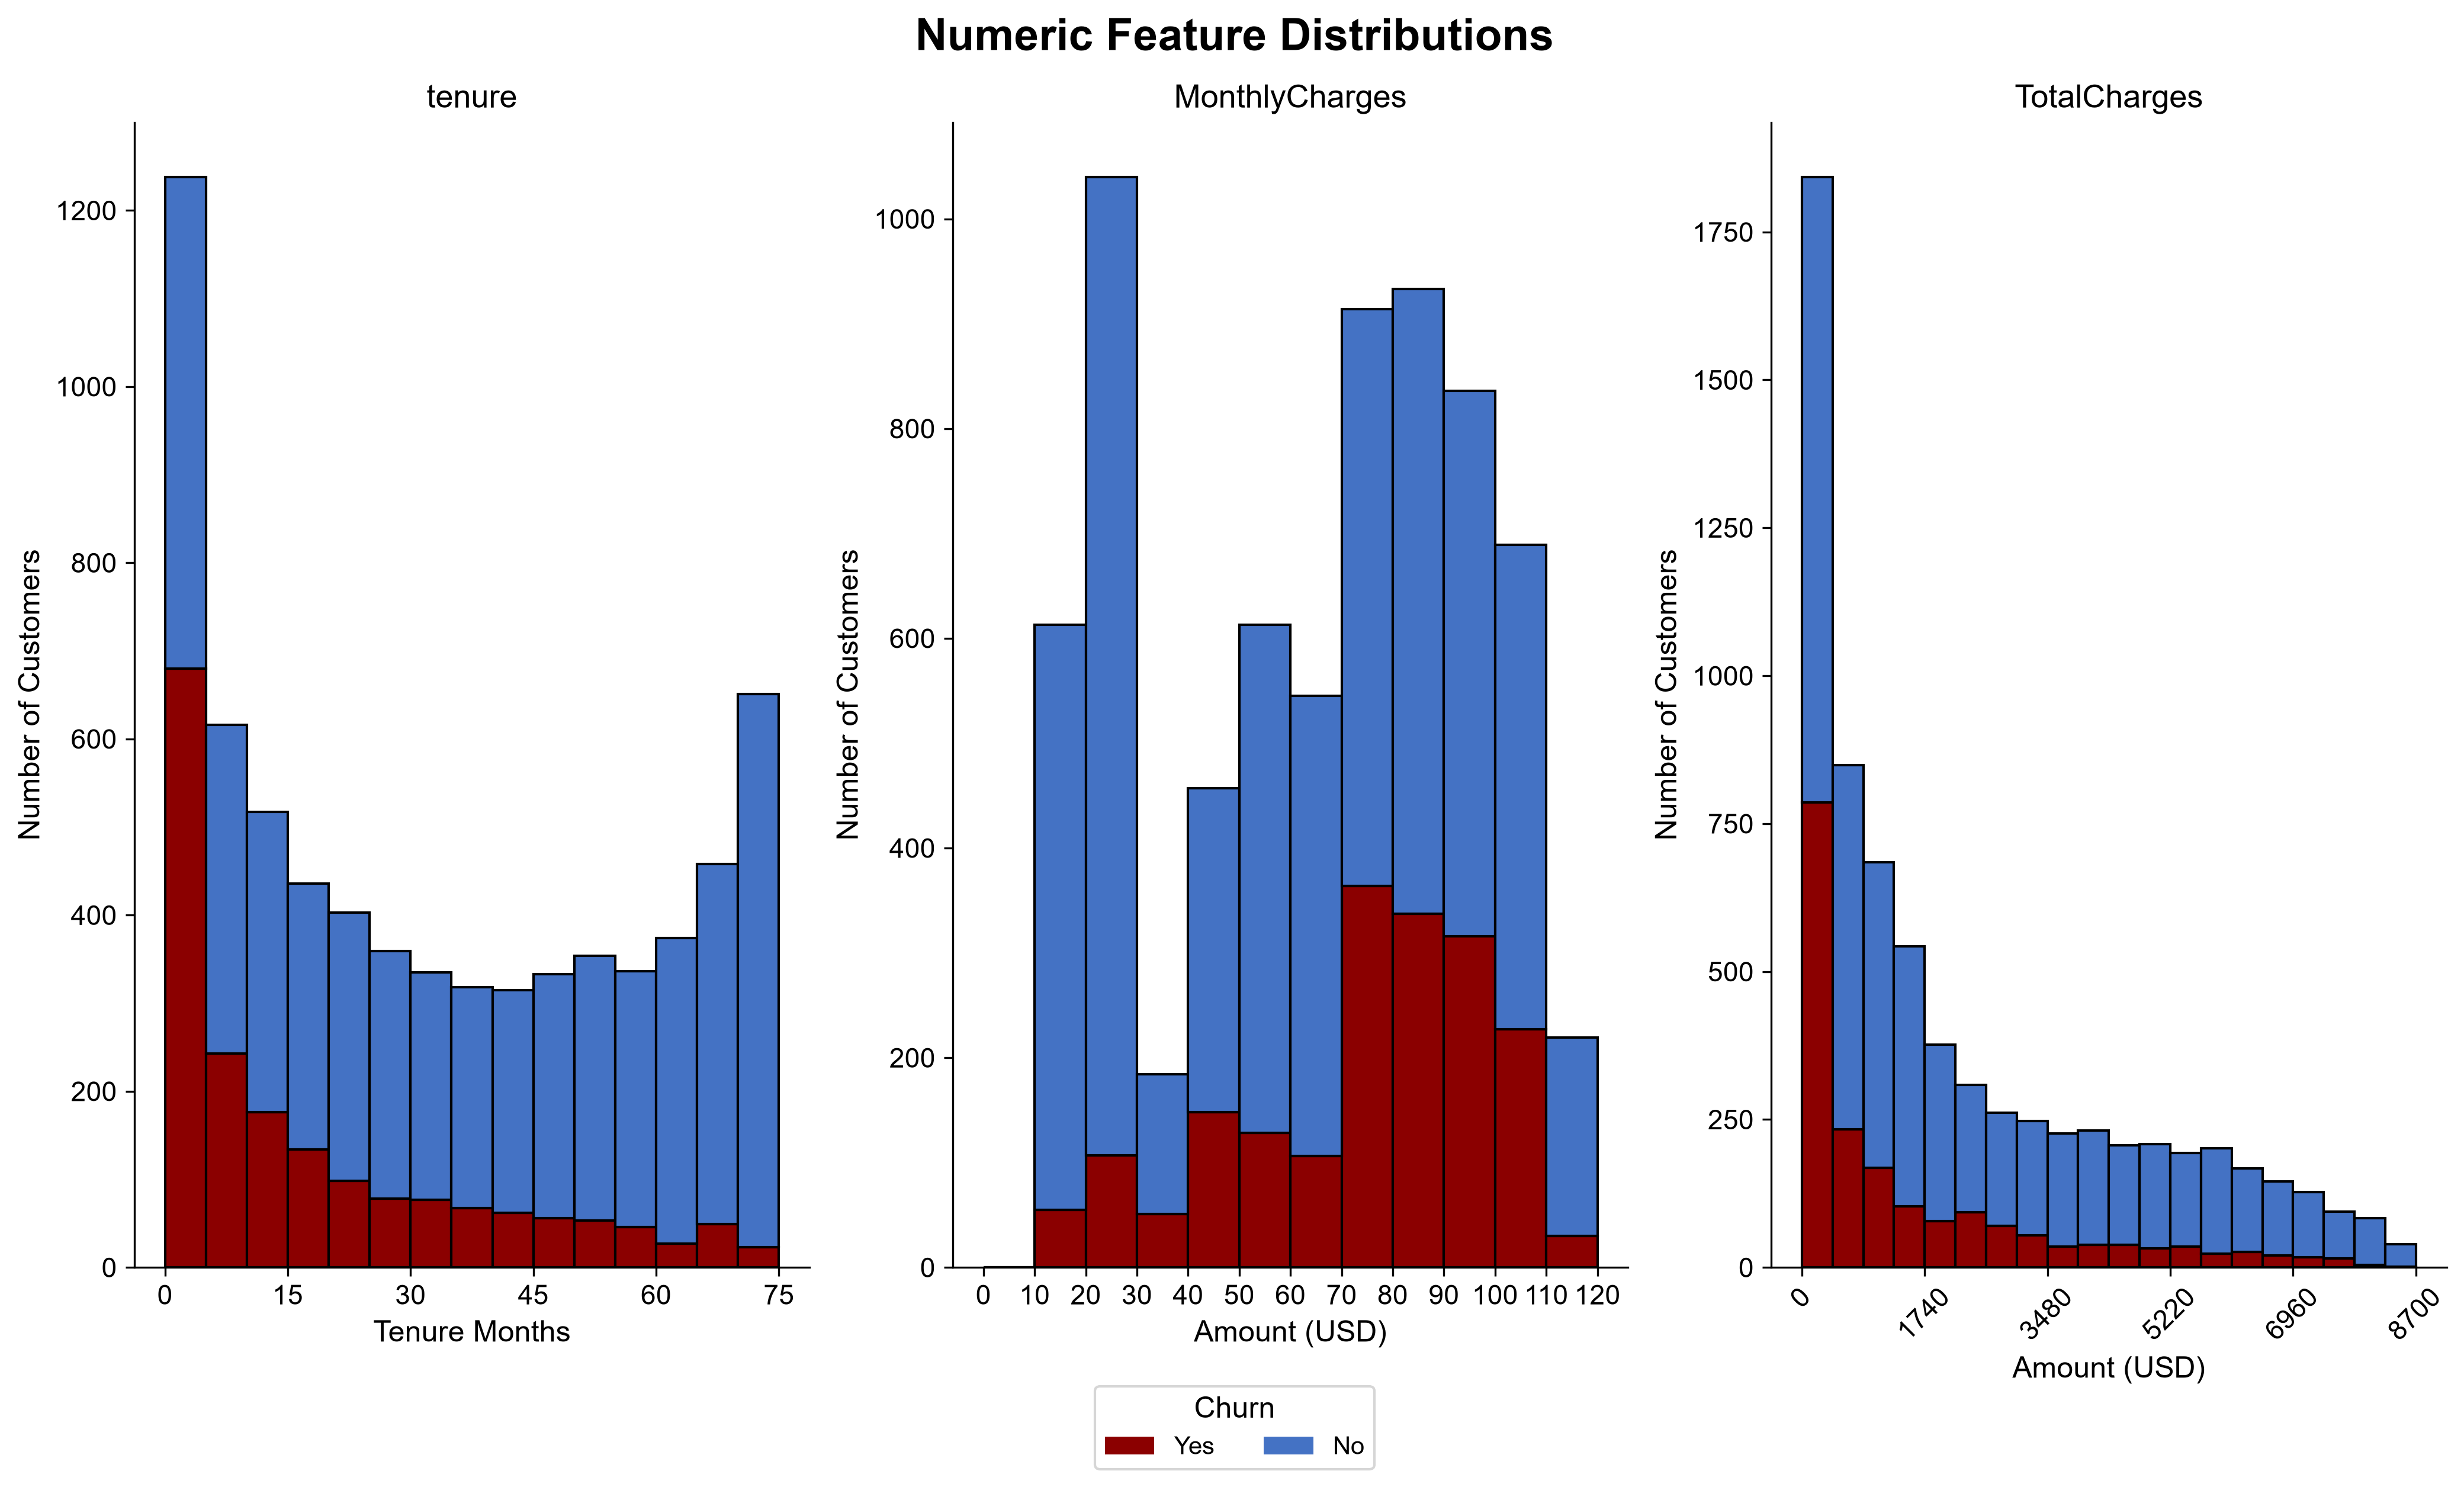

In [30]:
fig2, axes2 = plt.subplots(1, 3, figsize = (14,8), layout = "constrained")

# Produces histograms and formatting for each feature via 'plot_hist':
for dictionary, ax in zip(dicts_list, axes2):
    plot_hist(feature_df  = numeric_df, 
              feature = dictionary['feature'], 
              bin_edges = dictionary['bins'], 
              x_label = dictionary['xlabel_bins'], 
              axes = ax,
              rotation = dictionary['rotation'], 
              xlabel_bins = dictionary['tick_labels'])

fig2.legend(handles = bar_handles, loc = 'outside lower center', 
            bbox_to_anchor = (0.5, -0.4 / fig2.get_size_inches()[1]), 
            ncols = 2, title = 'Churn', title_fontsize = 12)

# global chart formatting:
plt.suptitle('Numeric Feature Distributions', fontsize = 18, fontweight = 'bold')

plt.tight_layout()                                    
plt.savefig('reports/figures/numeric_feature_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Extracts the four specified features into a dataframe `rate_num_df`:

In [31]:
rate_num_features = ['tenure', 'MonthlyCharges']
rate_num_features.append('Churn')
rate_num_df = churn_raw_df[rate_num_features]

Defines a function that cuts into a numeric feature and assigns each entry to a bin for specified bin edges and labels:

In [32]:
def assign_numeric_entry(feature_df, feature, edges):
    """
    Defines bin labels for each bin (based on bin edges), cuts into a numeric feature, assigns
    each entry to a predefined bin with specified bin edges and labels, and appends assigned bin 
    entries to a new column.

    Arguments:   
              feature_df (pandas.Dataframe) : DataFrame containing the categorical features, their 
                                              label entries and the corresponding target class.
              feature          (str object) : Feature name, passed as a string.
              edges          (array object) : Numeric bin edges, passed as an array.

    Output:  
              feature_df (pandas.Dataframe) : feature dataframe with appended column of assigned
                                              bin entries.
    """
    labels = [f'{edges[edge] + 1} \u2013 {edges[edge + 1]}' for edge in range(len(edges) - 1)]
    
    feature_df[f'{feature}_binned'] = pd.cut(feature_df[feature], 
                                             bins = edges, 
                                             labels = labels)
    return feature_df

Assigns each numeric entry in `tenure` and `MonthlyCharges` to a bin with predefined bin edges and labels, and appends bin values to new columns in `rate_num_df` via `assign_numeric_entry`:

In [33]:
tenure_bin_edges = np.arange(0, 73, 6)
MonthlyCharges_bin_edges = np.arange(10, 121, 10)

binned_features = rate_num_features
bin_edges = [tenure_bin_edges, MonthlyCharges_bin_edges]

for feature, edge in zip(binned_features, bin_edges):
    feats_df = assign_numeric_entry(feature_df = rate_num_df, 
                                    feature = feature,
                                    edges = edge)

Determines value counts and proportions of each feature in `feats_df` via `compute_count_percentages`:

In [34]:
# rearranges order of columns in 'rate_num_df':
rate_num_df = rate_num_df[['tenure_binned', 'MonthlyCharges_binned', 'Churn']]

rate_num_counts, rate_num_percentages = compute_count_percentages(rate_num_df)

Produces a visual of numeric features `tenure` and `MonthlyCharges` via `plot_features_grid` for a churn rate breakdown by numeric features:

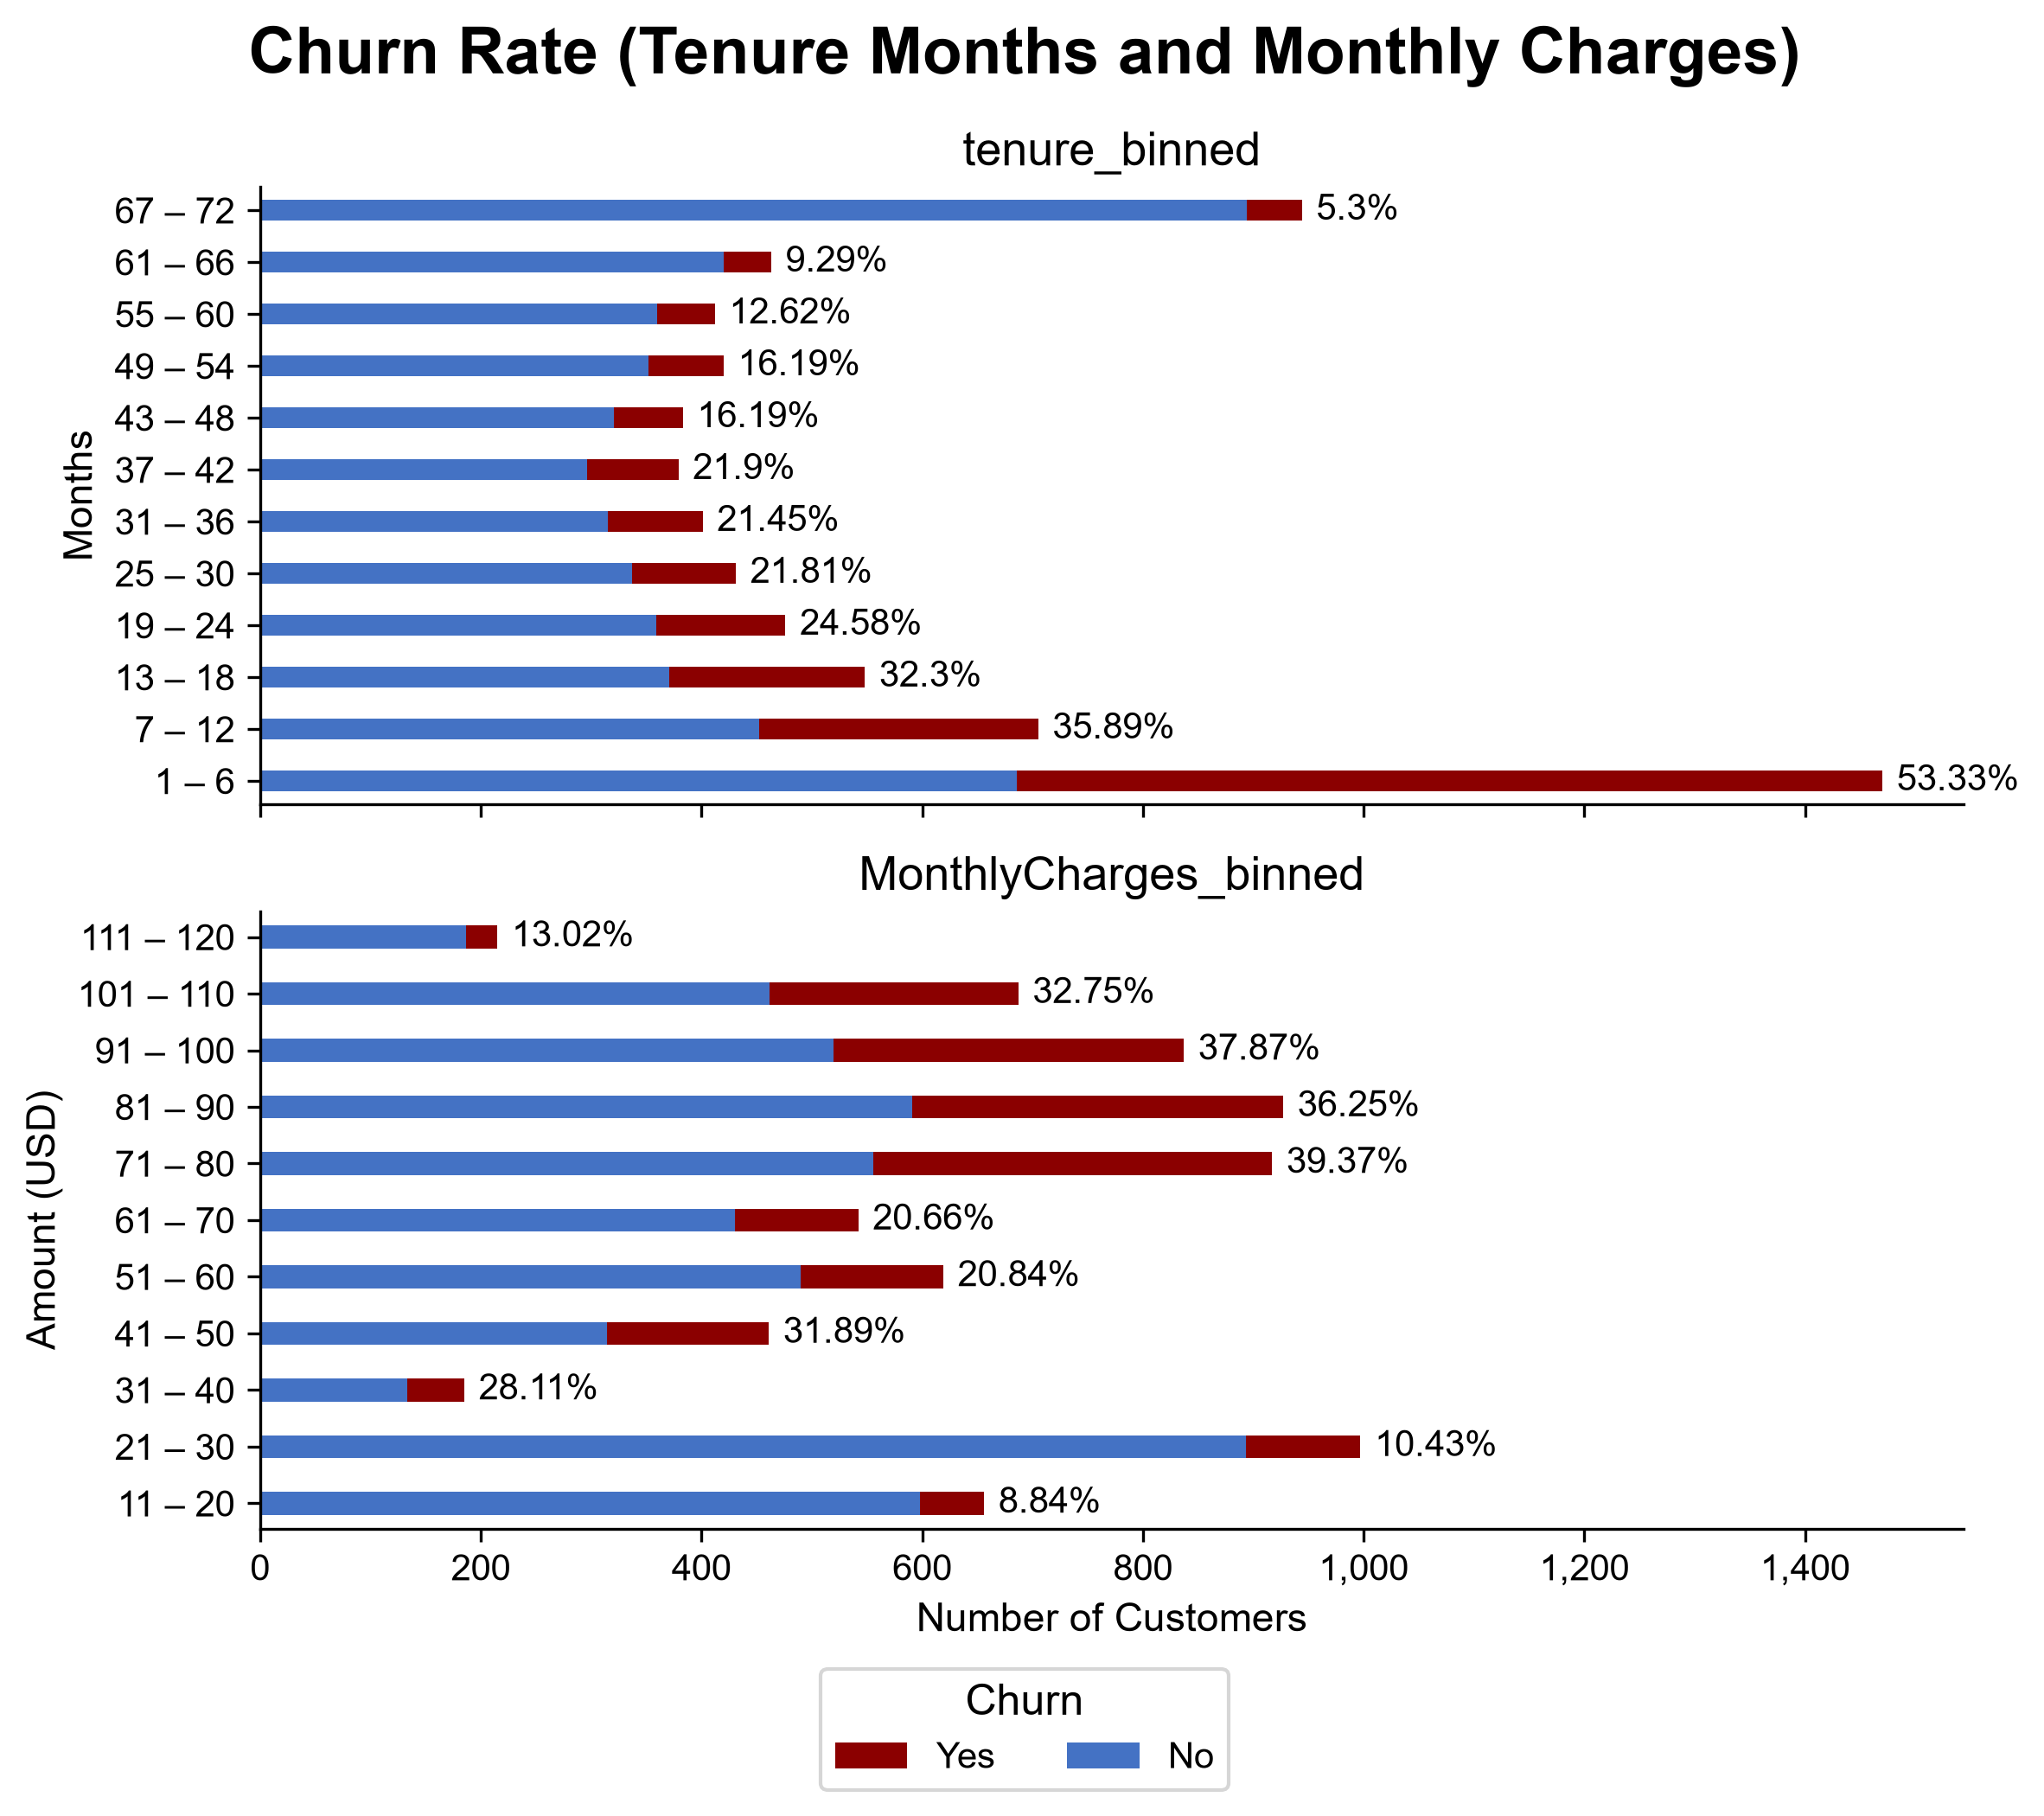

In [35]:
plot_features_grid(counts = rate_num_counts, 
                   percentages = rate_num_percentages, 
                   nrows = 2, ncols = 1, 
                   fig_size = (8,6.5),
                   y_label = ['Months', 'Amount (USD)'], 
                   global_title = 'Churn Rate (Tenure Months and Monthly Charges)',
                   filename = 'num_churn_rate_breakdown')

##### $\textbf{Intepretation (Numeric feature distributions)}$

Histograms of numeric features:

- `tenure`: Majority of customers have been with Telco for $30$ months and less, with both churners and non-churners clustering heavily at a low tenure of $0 - 10$ months. This spike, which is characterised by a large crimson portion, implies that newer customers churn at a much faster rate. The slight uptick in customer churn at $65 - 70$ months implies that long-tenured customers who were retained eventually leave, likely due to contract expiry. Furthermore, the distribution of churners is skewed significantly towards the lower tenure bands, further corraborating the faster churn rate of newer customers. 
  
- `MonthlyCharges`: Churners cluster significantly in higher charge bands ($70 - 100$ USD), which implies that higher-paying customers are more likely to leave. The lower charge bands ($10 - 70$ USD) are almost entirely blue, further confirming the aforementioned implication.

- `TotalCharges`: The distribution is heavily skewed to the lower total charge bands, with both churners and non-churners clustering significantly at lower total charges. This spike makes sense in context, as the newer customers with a high churn rate have not accumulated much total charges yet. 

Churn rate by tenure months and monthly charges:

- `tenure`: 
  
- `MonthlyCharges`:

##### $\textbf{Numeric feature correlation}$

##### This section explores the strength and direction of statistical relationships between the three numeric predictors `tenure`, `MonthlyCharges`, and `TotalCharges`, with the intention of investigating numeric-numeric feature redundancy.

Given that only numeric feature redundancy (and not target relevance) is being investigated here, target variable `Churn` is dropped from the referenced `num_df`, after which rank-based Spearman correlation is computed via `corr`:

In [36]:
num_df = numeric_df   # references numeric feature dataframe previously created

# drops 'Churn' column:
num_df = num_df.drop(columns = ['Churn'])

# computes Spearman correlation:
corr_df = num_df.corr(method = 'spearman')

*Note: Spearman correlation is selected over other approachs due to its suitability for heavily skewed and non-normally distributed continuous data, which is observed under the $\textbf{Numeric feature distributions}$ section via the produced histograms.*

Defines a function `plot_heatmap` that produces a heatmap of a dataframe with indexed rows and columns that comprise features:

In [37]:
def plot_heatmap(matrix_df, fig_size, c_map, annot_size, bounds, title, title_size, bar_label, file_name, map_mask = None):
    """
    Produces and saves (to file) a formatted visual of a heatmap displaying data with feature-indexed rows and columns
    with a specified colour scheme.

    Arguments:
              matrix_df  (pandas Dataframe) : Matrix of data that the heatmap plots.
              fig_size       (tuple object) : Dimensions of the figure.
              c_map              (Colormap) : Custom colourmap for the heatmap. 
              annot_size       (int object) : Size of data annotations.
              bounds         (tuple object) : Minimum and maximum boundaries for colour scale.
              title            (str object) : Title of the figure.
              title_size       (int object) : Size of the figure title. 
              bar_label        (str object) : Label for the heatmap colourbar. 
              file_name        (str object) : Name of visual saved to file.
              map_mask       (array object) : Array for hiding upper half of matrix.
    """
    figure, axes = plt.subplots(figsize = fig_size)

    sns.heatmap(matrix_df,
                cmap = c_map,        
                vmin = bounds[0], 
                vmax = bounds[1],
                fmt = '.2f',                 # float with 2 decimal places          
                annot = True,                  
                annot_kws = {'size': annot_size},
                linewidth = 0.4,
                ax = axes,
                mask = map_mask)
    
    # chart formatting:
    axes.tick_params(axis = 'both', labelsize = 11)
    axes.set_xlabel('Feature', fontsize = 12)
    axes.set_ylabel('Feature', fontsize = 12)
    axes.set_title(title, fontsize = title_size, fontweight = 'bold', pad = 8)
    
    colour_bar = axes.collections[0].colorbar 
    colour_bar.set_label(bar_label, fontsize = 12)
    
    plt.tight_layout()
    plt.savefig(f'reports/figures/{file_name}.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

Produces a visual of the Spearman correlation between numeric feature pairs via `plot_heatmap`:  

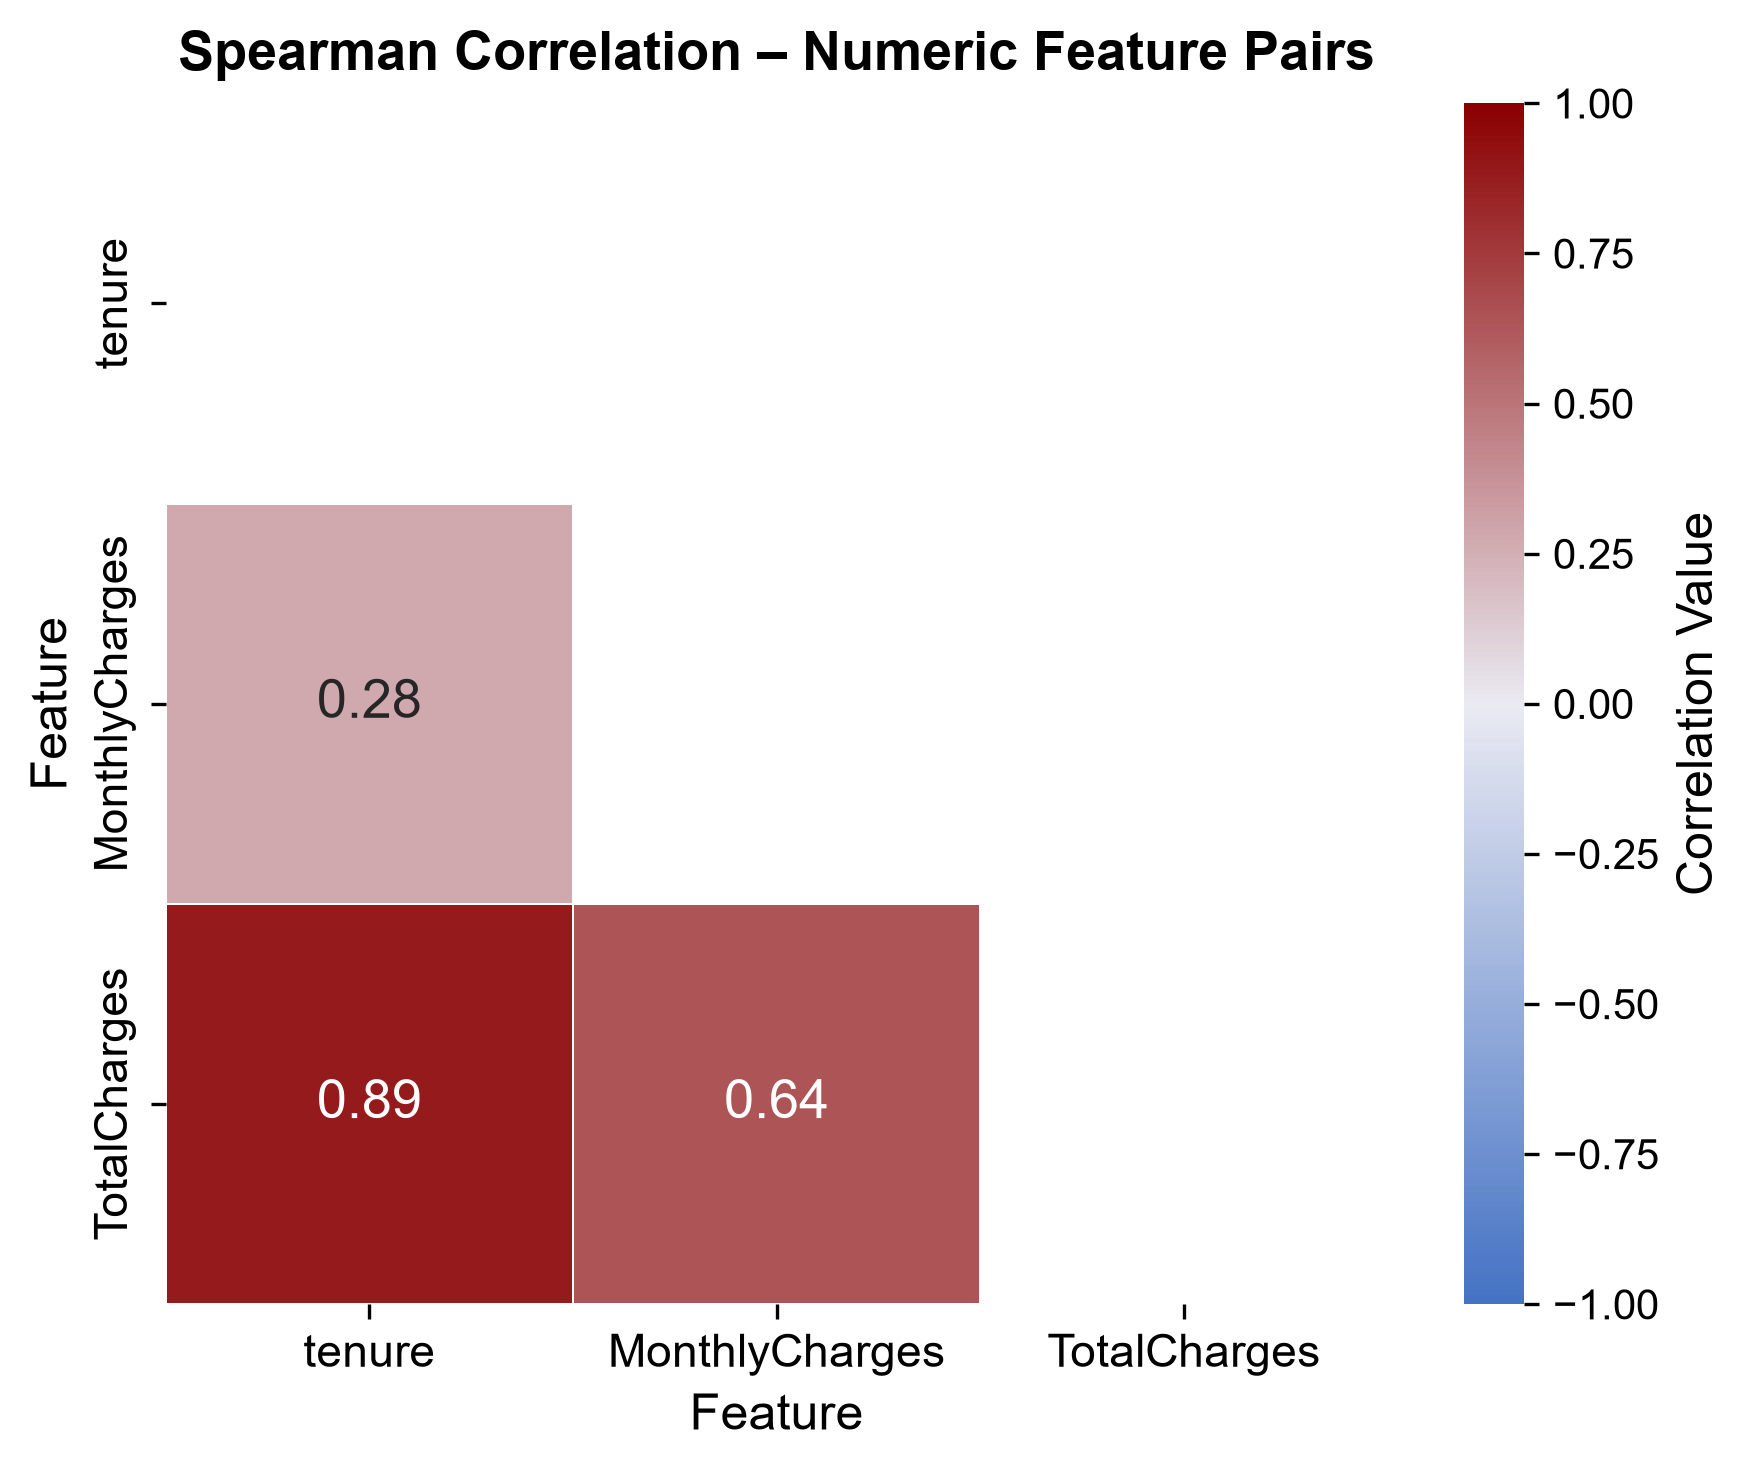

In [38]:
# blanks out cells in the upper matrix triangle and diagonal:
map_mask = np.triu(np.ones_like(corr_df, dtype = bool))

plot_heatmap(matrix_df = corr_df, 
             fig_size = (6,5), 
             c_map = custom_map_1,    # custom blue-grey-red colour map
             annot_size = 13, 
             bounds = (-1,1), 
             title = 'Spearman Correlation \u2013 Numeric Feature Pairs',  
             title_size = 13, 
             bar_label = 'Correlation Value', 
             file_name = 'numeric_feature_correlation', 
             map_mask = map_mask)

##### $\textbf{Intepretation (Numeric feature correlation)}$

$0.89$ - high `tenure` $\times$ `TotalCharges`

##### $\textbf{Categorical feature association}$

##### This section explores the significance and strength of statistical association for categorical feature pairs across the full categorical predictor set `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, and `PaymentMethod`, with the purpose of investigating categorical-categorical feature redundancy.

Creates a dictionary `crosstab_dict` containing contingency tables for every unique feature pair via `combinations` and `crosstab`:

In [39]:
# combines feature names through unpacking:
all_cat_features = [*two_cat_features, *three_cat_features, *rate_cat_features]  # no 'Churn', as feature redundancy is the focus 

cat_df = churn_raw_df[all_cat_features]

# generates unique feature pairs without duplicates or self-pairing:
pairs = list(combinations(all_cat_features, 2))   # combination length of 2 for pairs

# produces contingency tables for every feature pair, stored in a dictionary:
crosstab_dict = {f'{pair[0]}-{pair[1]}': pd.crosstab(cat_df[pair[0]], cat_df[pair[1]]) for pair in pairs}

Computes the chi-squared statistic, p-values, degrees of freedom, expected frequency table, and Cramér's V for each feature pair via `chi2_contingency`, and assesses the reliability of the chi-squared statistics (and resulting Cramér's V) for each pair:

In [40]:
# initialises dictionary for Cramér's V and chi-square statistic p-value:
cramer_v_dict = {}

# defines rule-of-thumb threshold that expected frequencies should exceed:
freq_threshold = 5

# initialises dictionary for feature pairs with expected frequencies that fall below threshold:
freq_dict = {}

# Computes the chi-squared statistics, associated outputs and Cramér's V for each feature pair:
for pair in crosstab_dict.keys():
    chi2_stat, p_val, dof, expected_freq = chi2_contingency(crosstab_dict[pair])
    nrows = crosstab_dict[pair].shape[0]
    ncols = crosstab_dict[pair].shape[1]
    # Calculates Cramér's V:
    cramer_v = math.sqrt(chi2_stat / (cat_df.shape[0] * min([nrows - 1,ncols - 1])))
    cramer_v_dict[pair] = [cramer_v, p_val]
    # determines if any frequency values fall below rule-of-thumb threshold:
    if (expected_freq < freq_threshold).any():
        freq_dict[pair] = np.where(expected_freq < freq_threshold)
        
# checks if frequency dictionary is empty, and if so, removes it from memory:
if not freq_dict:
   print('All chi-squared statistics reliable!')
   del freq_dict    

All chi-squared statistics reliable!


Given that every cell in the expected frequency tables meet the criteria of exceeding the conventional rule-of-thumb threshold, the core assumption of the chi-squared test is validated, meaning that the chi-squared statistic (and corresponding p-value) for every feature pair are deemed reliable for independence testing. 

*Note:*
- *Chi-squared test is selected over other methods for several reasons, including: (1) it being a well-established method for testing independence between categorical features, (2) its suitability for nominal features with no inherent ranking to exploit, and (3) its ability to naturally scale to contigency tables of any dimension.*
- *Cramér's V is selected in addition to the chi-squared test to provide a singular, bounded, comparable measure of the statistical association strength for feature pairs with varying table dimensions.*

Creates an "empty" dataframe `cramerv_df` with indexed rows and columns using the categorical feature names, and populates it with the Cramér's V for each feature pair:

In [41]:
# creates row and column names for indexing:
row_names = all_cat_features
col_names = all_cat_features

# dataframe with missing values and indexed rows and columns:
cramerv_df = pd.DataFrame(data = np.nan, index = row_names, columns = col_names)

# populates lower triangle of `cramerv_df` with Cramér's V:
for pair in pairs:
    cramerv_df.loc[pair[1], pair[0]] = cramer_v_dict[f'{pair[0]}-{pair[1]}'][0]

Produces a visual of the Cramér's V for each categorical feature pair via `plot_heatmap`:

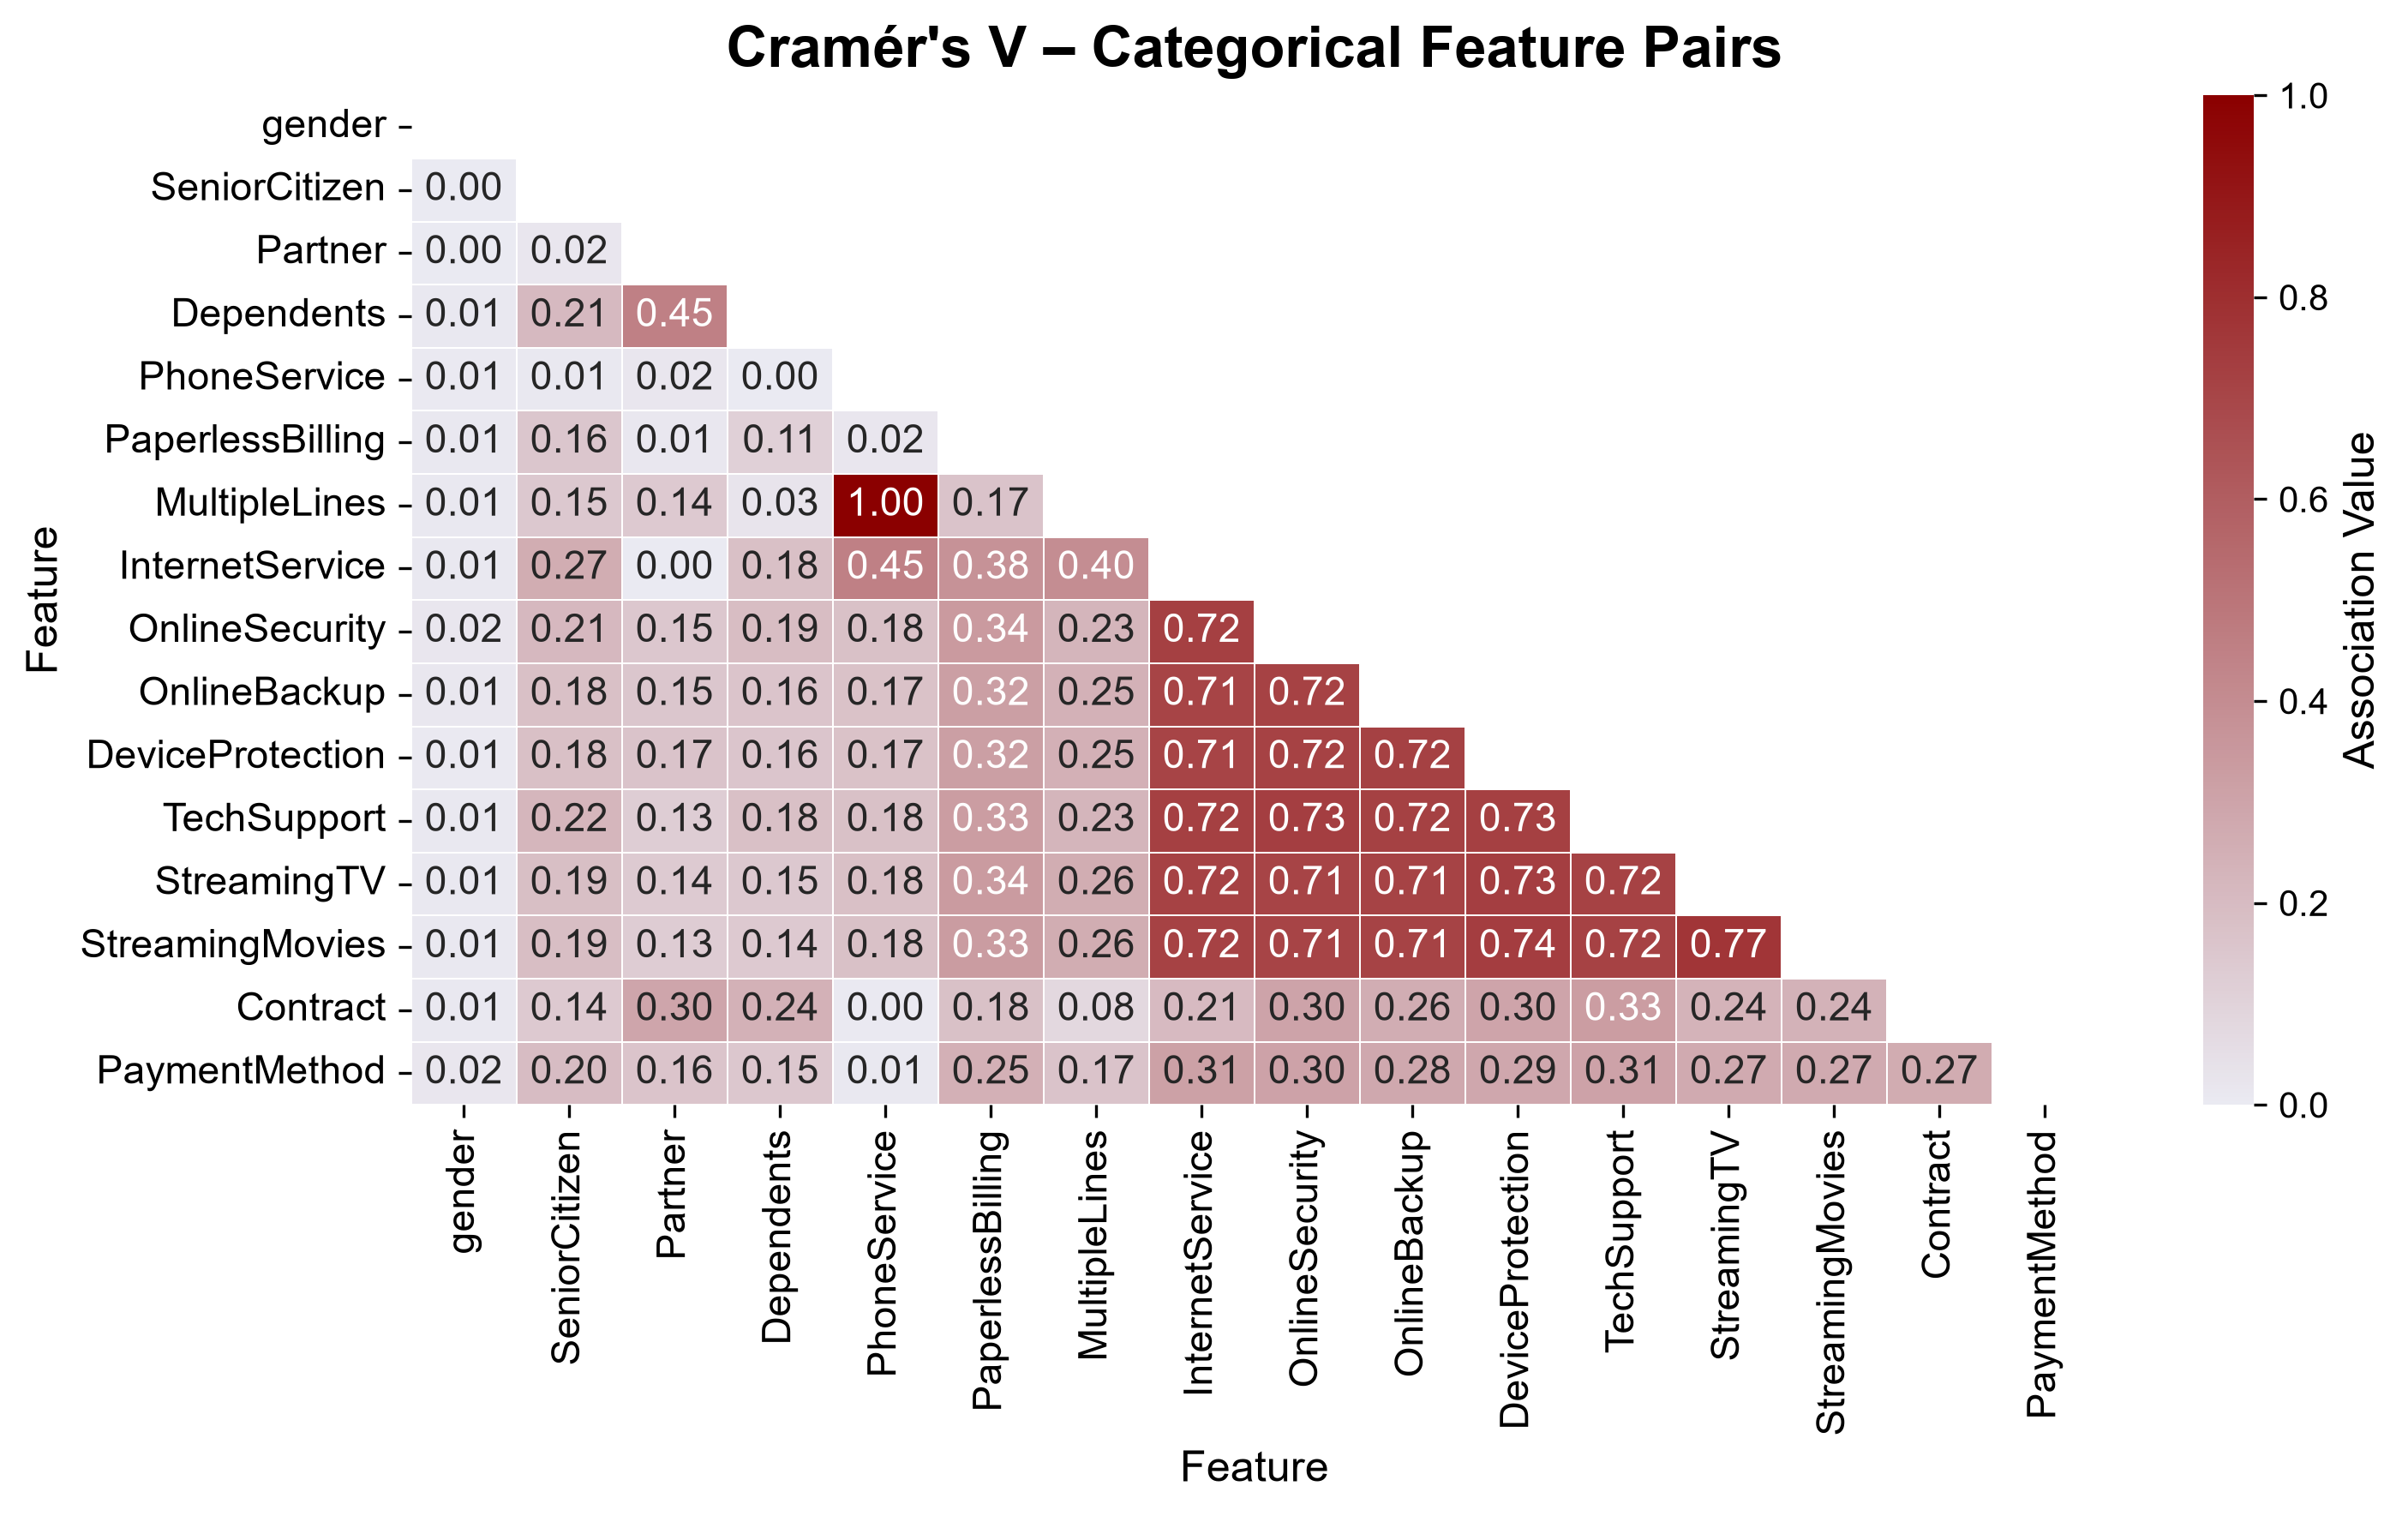

In [42]:
plot_heatmap(matrix_df = cramerv_df, 
             fig_size = (10,6), 
             c_map = custom_map_2,         # custom grey-red colour map
             annot_size = 11, 
             bounds = (0,1), 
             title = "Cramér's V \u2013 Categorical Feature Pairs",  
             title_size = 16, 
             bar_label = 'Association Value', 
             file_name = 'categorical_feature_association')

##### $\textbf{Intepretation (Categorical feature association)}$

##### $\textbf{Categorical-numeric feature correlation}$

##### This section explores the significance and strength of statistical association for categorical-numeric feature pairs across the full predictor set `tenure`, `MonthlyCharges`, `TotalCharges`, `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, and `PaymentMethod`, with the purpose of investigating categorical-numeric feature redundancy.

Extracts dataframe `feats_df` with the full predictor set, and converts `TotalCharges` entries to numeric via `to_numeric`:

In [43]:
num_features = num_df.columns.tolist() # references numeric feature names from dataframe created previously
cat_features = all_cat_features        # references categorical feature names established previously

# feature names via unpacking:
all_features = [*num_features, *cat_features]

feat_df = churn_raw_df[all_features]

# converts 'TotalCharges' entries to numeric:
feat_df['TotalCharges'] = pd.to_numeric(feat_df['TotalCharges'], errors = 'coerce')

Generates every unique categorical-numeric feature pair via a cross product, and defines dictionary `num_cat_dict` containing the mean numeric value and total number of numeric entries per categorical group for each feature pair:

In [44]:
feat_pairs = list(product(all_cat_features, num_features))   # categorical feature names first for indexing purposes:

num_cat_dict = {f'{pair[0]}-{pair[1]}': feat_df.groupby(pair[0])[pair[1]].agg(['mean','count']) for pair in feat_pairs}

Determines the overall mean across all rows of the numeric features, and computes the total unpartitioned variance in the numeric features with a sum of squares, stored in dictionary `ss_total_num`:

In [45]:
num_grand_mean = num_df.mean()

# initialises sum of squares dictionary:
ss_total_num = {}

# loops over each numeric feature to determine total sum of squares:
for feature in num_features:
    ss_feature = ((num_df[feature] - num_grand_mean[feature]) ** 2).sum()
    ss_total_num[feature] = ss_feature

Calculates the sum of squares between categorical groups and correlation ratio for each categorical-numeric feature pair, stored to dictionary `corr_ratio_dict`:

In [46]:
# initialises correlation ratio dictionary:
corr_ratio_dict = {}

# loops over each feature pair for in-between sum of squares and correlation ratio:
for pair in feat_pairs:
    pair_name = f'{pair[0]}-{pair[1]}'
    cat_mean = num_cat_dict[pair_name]['mean']
    cat_count = num_cat_dict[pair_name]['count']
    # in-between sum of squares:
    ss_between = (cat_count * ((cat_mean - num_grand_mean[pair[1]]) ** 2)).sum()
    corr_ratio_dict[pair_name] = ss_between / ss_total_num[pair[1]]

Creates an "empty" dataframe `corr_ratio_df` with indexed rows and columns (numeric and categorical features respectively), and subsquently populates it with correlation ratio values for each feature pair:

In [47]:
corr_rows = num_features
corr_cols = cat_features

# creates "empty" indexed dataframe with missing values:
corr_ratio_df = pd.DataFrame(data = np.nan, index = corr_rows, columns = corr_cols)

# populates dataframe with correlation ratio values for each feature pair:
for pair in feat_pairs:
    corr_ratio_df.loc[pair[1], pair[0]] = corr_ratio_dict[f'{pair[0]}-{pair[1]}']

Produces a visual of the correlation ratio values for each categorical-numeric feature pair via `plot_heatmap`:

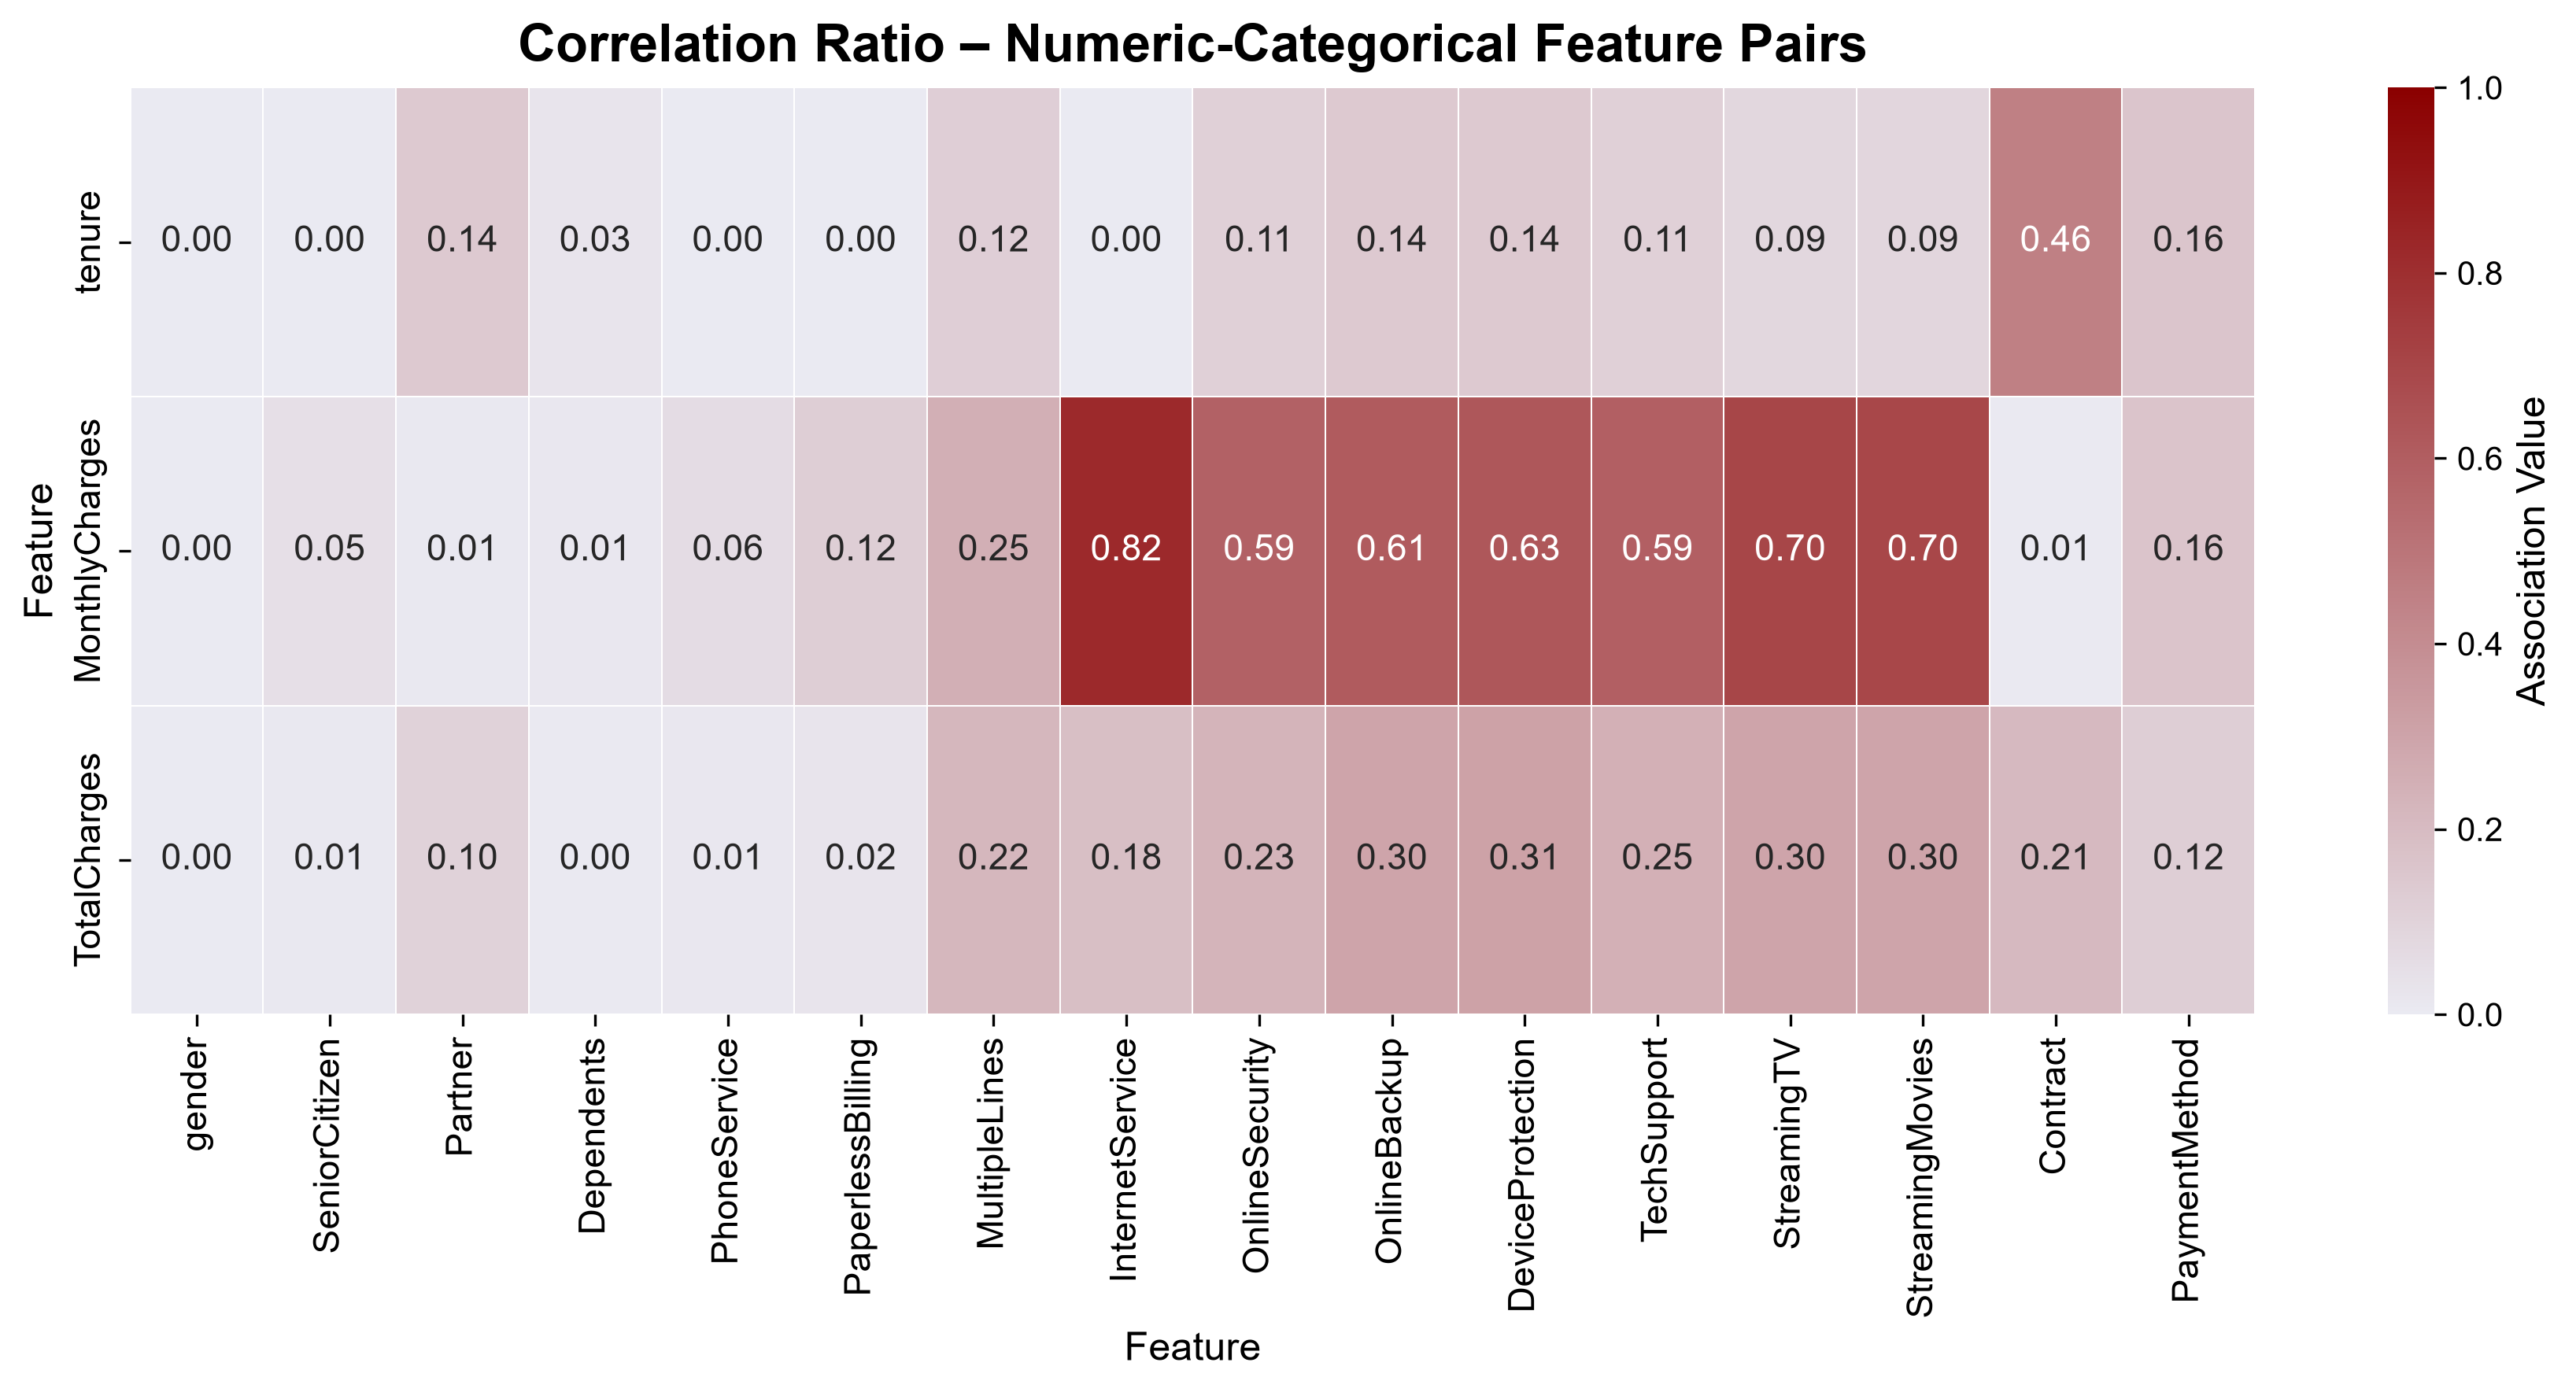

In [48]:
plot_heatmap(matrix_df = corr_ratio_df, 
             fig_size = (12,6), 
             c_map = custom_map_2,         # custom grey-red colour map
             annot_size = 11, 
             bounds = (0,1), 
             title = "Correlation Ratio \u2013 Categorical-Numeric Feature Pairs",  
             title_size = 16, 
             bar_label = 'Association Value', 
             file_name = 'numeric_categorical_association')

##### $\textbf{Intepretation (Categorical-numeric feature association)}$

##### $\textbf{Notebook Outputs}$

The output of this notebook is as follows: nine visualisations `target_class_bar_chart.png`, `two_cat_feature_distributions.png`, `three_cat_feature_distributions.png`, `cat_churn_rate_breakdown.png`, `numeric_feature_distribution.png`, `num_churn_rate_breakdown.png`, `categorical_feature_association.png`, `numeric_feature_correlation.png`, and `numeric_categorical_association.png`, all of which are saved to `reports/figures/`. All nine outputs are ready for use in subsequent pipeline stages. 

##### $\textbf{Technique Limitations}$